# Objectif 

Illustration de la propagation dans le guide d'onde de Pekeris utilisé pour la présentation du rapport des fonctions de transfert et pour l'étude de sensibilité. 

Le guide d'onde est un guide d'onde de Pekeris, constitué donc de deux couches fluides dont les propriétés sont les suivantes : 
* dans la colonne d'eau :
    * $c_0 = 1500 m/s$
    * $\rho_0 = 1000 kg/m^3$
* dans le sédiment : 
    * $c_1 = 1600 m/s$
    * $\rho_1 = 1500 kg/m^3$

In [1]:
import sys
import numpy as np

In [2]:
root_project = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
sys.path.append(root_project)

from illustration_rtf.src.sensitivity import (
    baseline_env,
    baseline_sig,
    baseline_src_rcv,
    calc_gamma_dist,
    calc_mainlobe_width_3dB,
    calc_monotonicity_domain, 
    run_single_sensibility_test,
)
from source.normal_modes import * 
from publication.publication_figure import color, set_subfigures_abc_labels

# Chargement de l'environnement 

In [3]:
# Environment
env_param = baseline_env()
print("Baseline environement properties:")
for k in env_param.keys():
    print(f"\t{k} = {env_param[k]}")

# Signal
sig_param = baseline_sig()
print("Baseline signal properties:")
for k in sig_param.keys():
    print(f"\t{k} = {sig_param[k]}")

# Source receiver config
src_rcv_param = baseline_src_rcv()
print("Baseline src / rcv configuration:")
for k in src_rcv_param.keys():
    print(f"\t{k} = {src_rcv_param[k]}")

Baseline environement properties:
	c1 = 1500
	c2 = 1600
	rho1 = 1000.0
	rho2 = 1500.0
	attn2 = 0.0
	depth = 100
Baseline signal properties:
	freq = [  0.    0.2   0.4   0.6   0.8   1.    1.2   1.4   1.6   1.8   2.    2.2
   2.4   2.6   2.8   3.    3.2   3.4   3.6   3.8   4.    4.2   4.4   4.6
   4.8   5.    5.2   5.4   5.6   5.8   6.    6.2   6.4   6.6   6.8   7.
   7.2   7.4   7.6   7.8   8.    8.2   8.4   8.6   8.8   9.    9.2   9.4
   9.6   9.8  10.   10.2  10.4  10.6  10.8  11.   11.2  11.4  11.6  11.8
  12.   12.2  12.4  12.6  12.8  13.   13.2  13.4  13.6  13.8  14.   14.2
  14.4  14.6  14.8  15.   15.2  15.4  15.6  15.8  16.   16.2  16.4  16.6
  16.8  17.   17.2  17.4  17.6  17.8  18.   18.2  18.4  18.6  18.8  19.
  19.2  19.4  19.6  19.8  20.   20.2  20.4  20.6  20.8  21.   21.2  21.4
  21.6  21.8  22.   22.2  22.4  22.6  22.8  23.   23.2  23.4  23.6  23.8
  24.   24.2  24.4  24.6  24.8  25.   25.2  25.4  25.6  25.8  26.   26.2
  26.4  26.6  26.8  27.   27.2  27.4  27.6  27.8  2

In [4]:
# Environment
c1 = env_param.get("c1", None)
c2 = env_param.get("c2", None)
rho1 = env_param.get("rho1", None)
rho2 = env_param.get("rho2", None)
attn2 = env_param.get("attn2", None)
d = env_param.get("depth", None)

# Signal
freq = sig_param.get("freq", None)
fs = sig_param.get("fs", None)
fmax = sig_param.get("fmax", None)

# Source / receiver
z_s = src_rcv_param.get("z_s", 5)
z = src_rcv_param.get("z_rcv", 20)
r_grid = src_rcv_param.get("r_rcv", np.array([1e4]))
r0 = src_rcv_param.get("r0", 1e4)
d12 = src_rcv_param.get("d12", 100)

# Illustration des modes 

In [5]:
###### Modal group and phase speed ######
# Angular freq
omega = 2 * np.pi * freq
# Horizontal wavenumbers
krm = pekeris_kr_m(freq, c1, c2, rho1, rho2, d)
# Phase speeds
cpm = cp_m(krm=krm, omega=omega[:, np.newaxis])
# Group speeds
cgm = pekeris_cg_m(freq, krm, c1, c2, rho1, rho2, d)

In [6]:
pekeris_n_modes(fmax, c1, c2, d)

7

## Vitesse de phase et de groupe 

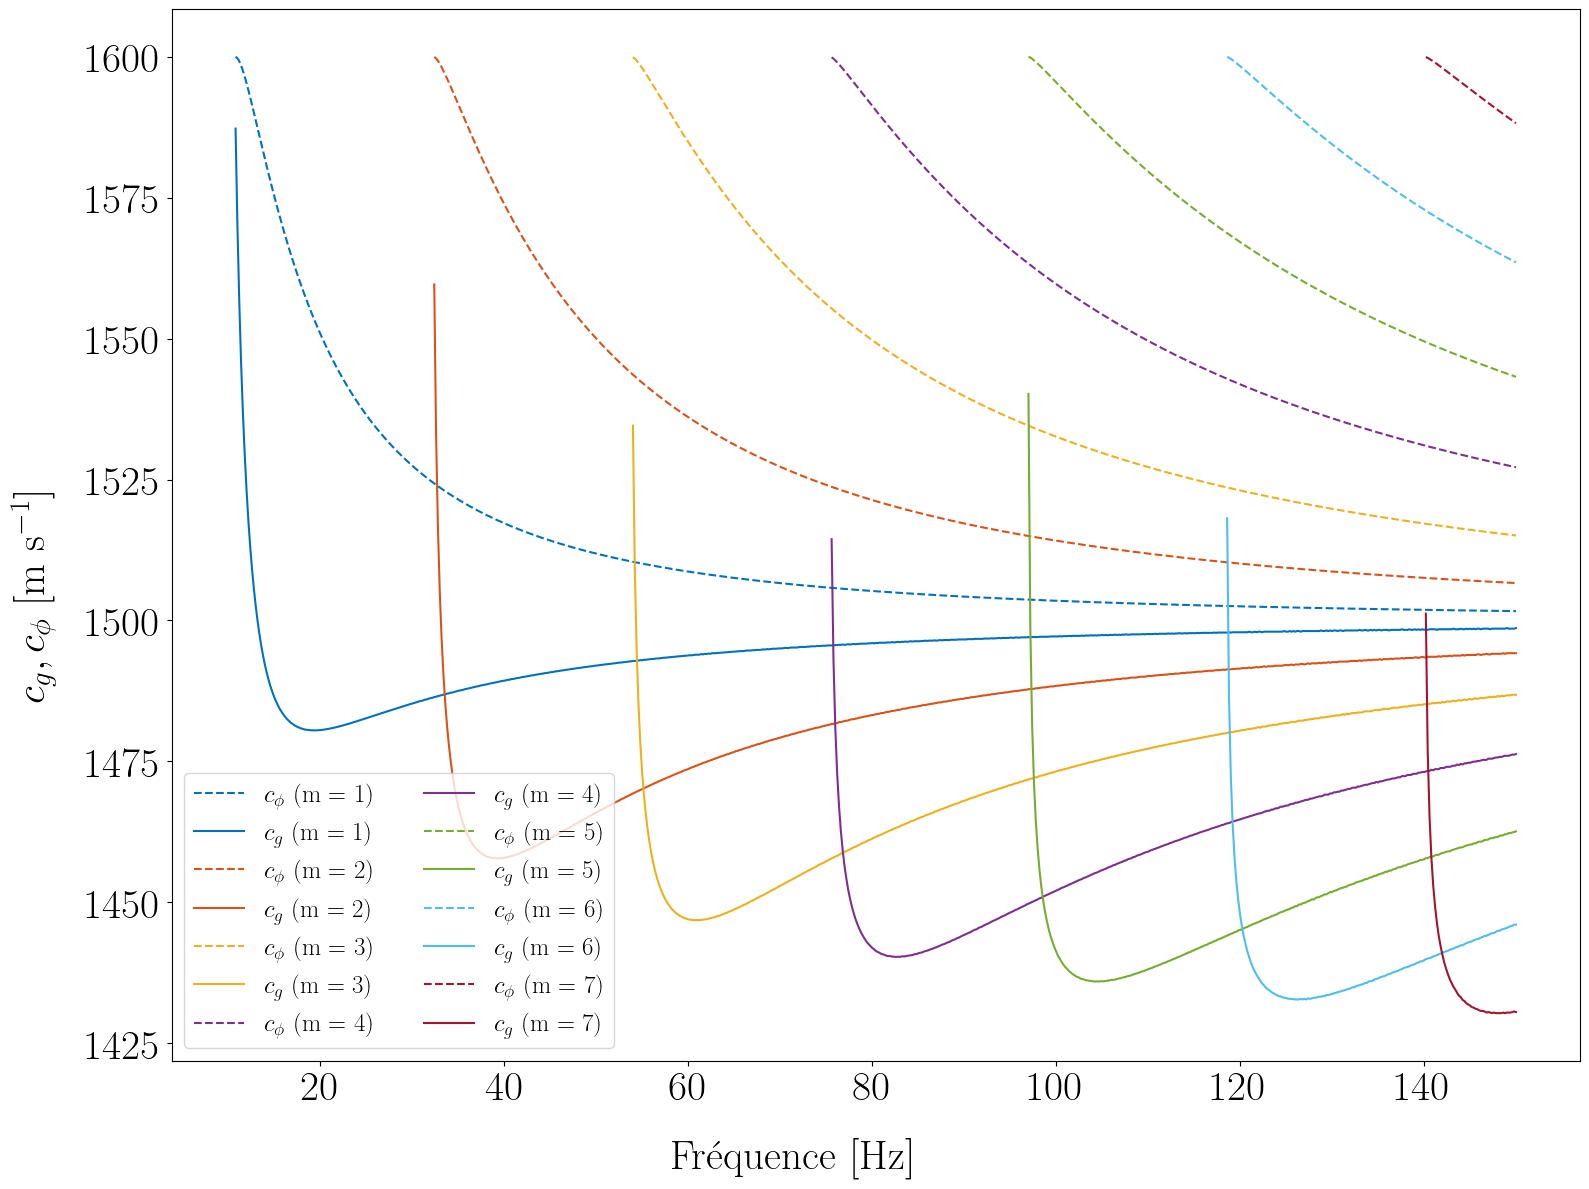

In [7]:
# Plot
fig, axs = plot_pekeris_cp_cg_f(f=freq, cpm=cpm, cgm=cgm)
plt.legend(fontsize=18, ncol=2, loc="lower left")

## Fonctions modales 


C:\Users\baptiste.menetrier\Desktop\devPy\phd\source\normal_modes.py:330: RuntimeWarning: invalid value encountered in sqrt
  idx_krm_lt_k2, np.sqrt(k2**2 - krm**2), 1j * np.sqrt(krm**2 - k2**2)


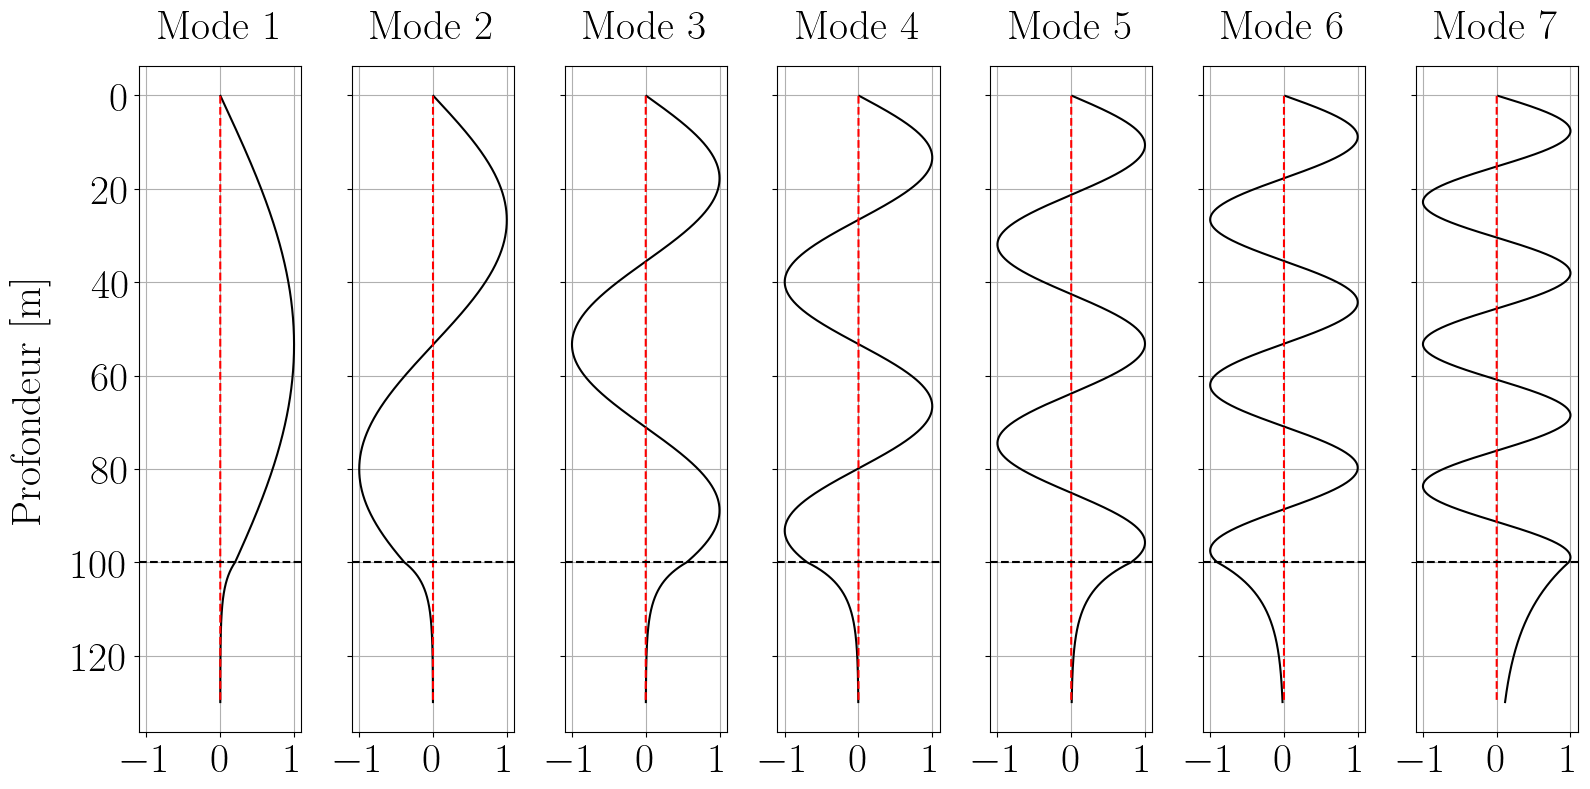

In [8]:
###### Modal function ######
dz = 0.1
zphi = np.arange(dz, d + 30, dz)
phim_arr = pekeris_modal_fct(zphi, freq, c1, c2, d, krm)

f0 = fmax
idx_f0 = np.argmin(np.abs(freq - f0))
phim_f0 = phim_arr[idx_f0, ...]

M_f0 = np.max(pekeris_n_modes(f0, c1, c2, d))
fig, axs = plot_modal_function(modal_fcts=phim_f0, z=zphi, depth=d, n_modes=M_f0)

(<Figure size 1600x800 with 5 Axes>,
 array([<Axes: title={'center': 'Mode 1'}, ylabel='Profondeur [m]'>,
        <Axes: title={'center': 'Mode 2'}>,
        <Axes: title={'center': 'Mode 3'}>,
        <Axes: title={'center': 'Mode 4'}>,
        <Axes: title={'center': 'Mode 5'}>], dtype=object))

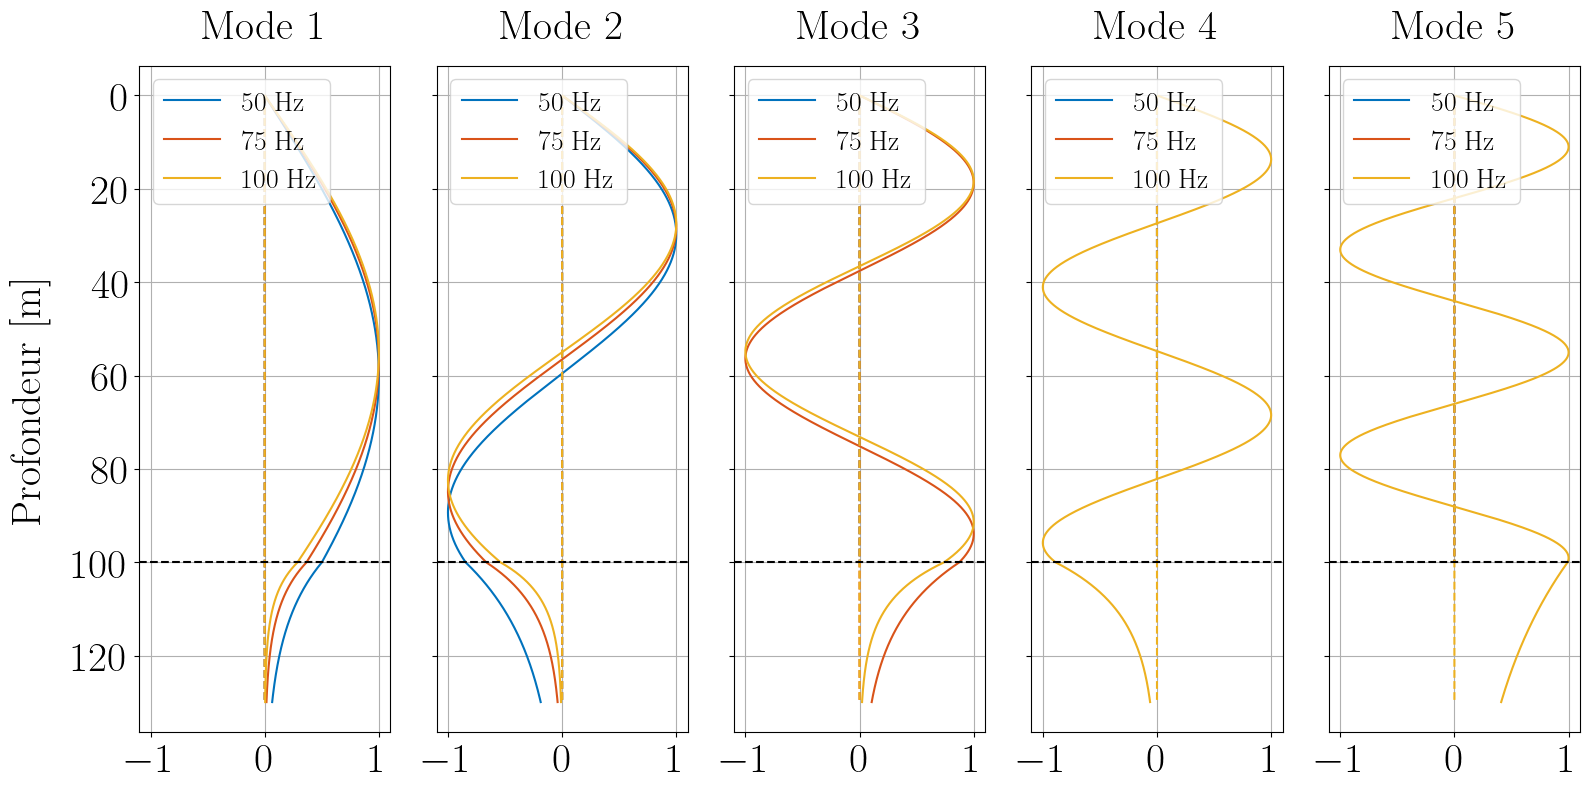

In [9]:
# Multi freq
fplot = [50, 75, 100]
idx_fplot = [np.argmin(np.abs(freq - f)) for f in fplot]
phim_fplot = phim_arr[idx_fplot, :]
M_fplot = np.max(pekeris_n_modes(fplot, c1, c2, d))
plot_modal_function(modal_fcts=phim_fplot, z=zphi, f=fplot, depth=d, n_modes=M_fplot)

# Réponse temporelle du guide d'onde 

## Calcul de la réponse 

In [10]:
###### Green's function at z, r ######
gf = pekeris_green_fct(freq, c1, c2, rho1, rho2, attn2, d, z_s, z, r0)
gf = gf.squeeze()

C:\Users\baptiste.menetrier\Desktop\devPy\phd\source\normal_modes.py:608: RuntimeWarning: divide by zero encountered in divide
  lambd = c / f
C:\Users\baptiste.menetrier\Desktop\devPy\phd\source\normal_modes.py:572: RuntimeWarning: invalid value encountered in divide
  (1j * alpha_2_2d * omega_2d)
C:\Users\baptiste.menetrier\Desktop\devPy\phd\source\normal_modes.py:506: RuntimeWarning: invalid value encountered in divide
  Am[..., np.newaxis]


In [11]:
# Impulse response
output_mult_fact = 2
tau = r0 / max(c1, c2)  # Minimum arrival time
t, gt = impulse_response(gf, freq, fs, tau=tau, output_mult_fact=output_mult_fact)

## Illustration 

(<Figure size 1600x800 with 1 Axes>,
 <Axes: title={'center': 'z_s = 5.0 m, z_r = 99.5 m, r = 50000.0 m'}, xlabel='Temps réduit $t - r / c_{max}$ [s]', ylabel='h(t) [Pa]'>)

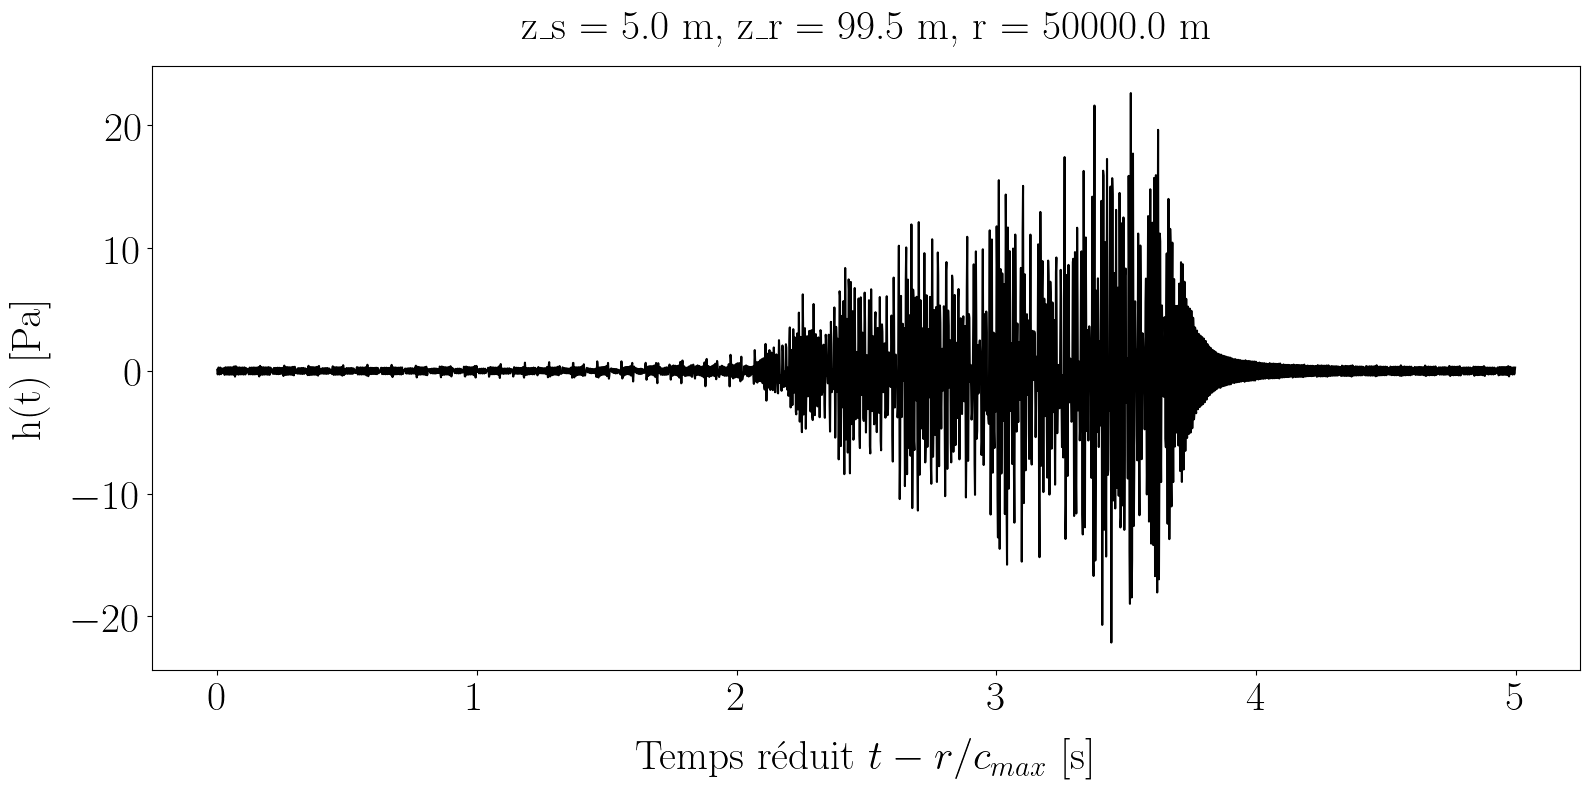

In [12]:
plot_impulse_response(t, gt, z_s, z, r0)

In [13]:
spl = 20* np.log10(20 * 1e6)
print(f"SPL {spl:.1f} dB")

SPL 146.0 dB


(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: ylabel='h(t) [Pa]'>, <Axes: ylabel='Fréquence [Hz]'>],
       dtype=object))

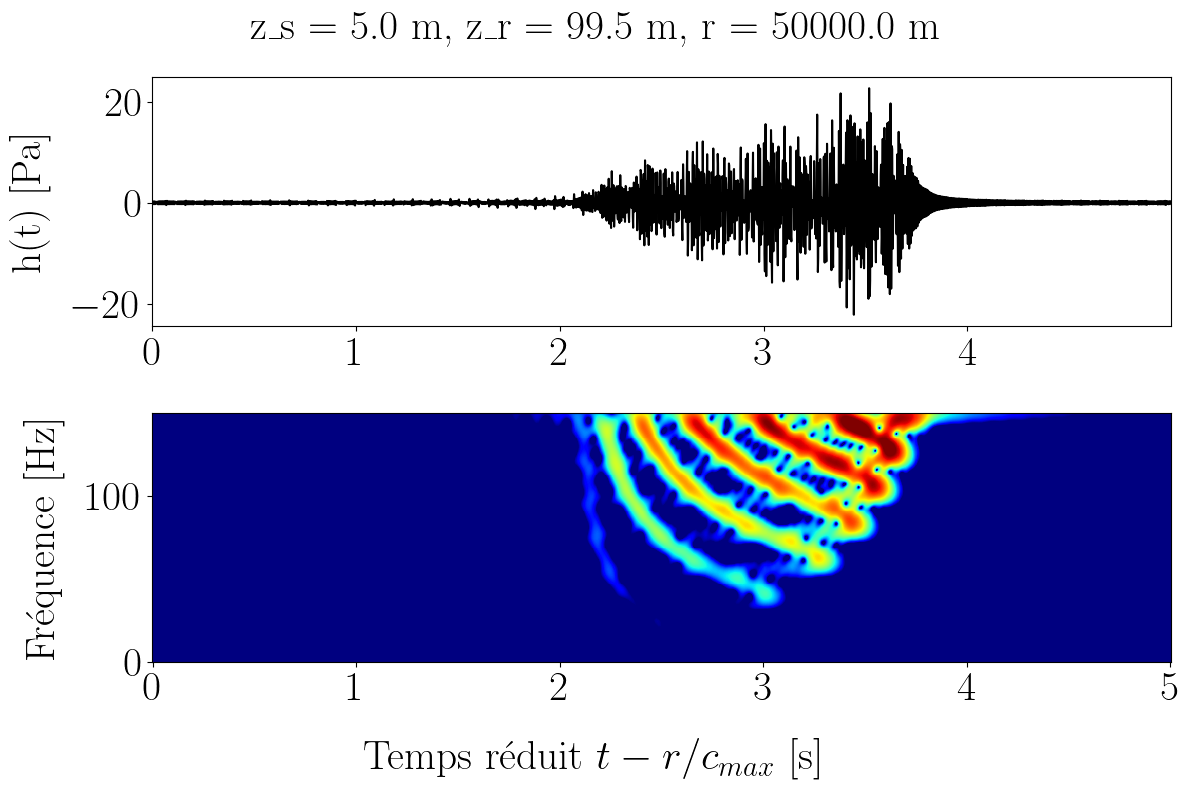

In [14]:
# stft
# Réglage identique au code du tuto de J.Bonnel
nfft = 1024
nperseg = 51 * output_mult_fact
noverlap = nperseg - 1

plot_impulse_response_and_stft(
    t,
    gt,
    z_s,
    z,
    r0,
    fmax,
    nfft=nfft,
    nperseg=nperseg,
    noverlap=noverlap,
    stft_vmin_percentile=90,
    stft_vmax_percentile=99.9,
)

(<Figure size 1600x800 with 1 Axes>,
 <Axes: title={'center': 'z_s = 5.0 m, z_r = 99.5 m, r = 50000.0 m'}, xlabel='Temps réduit $t - r / c_{max}$ [s]', ylabel='Fréquence [Hz]'>)

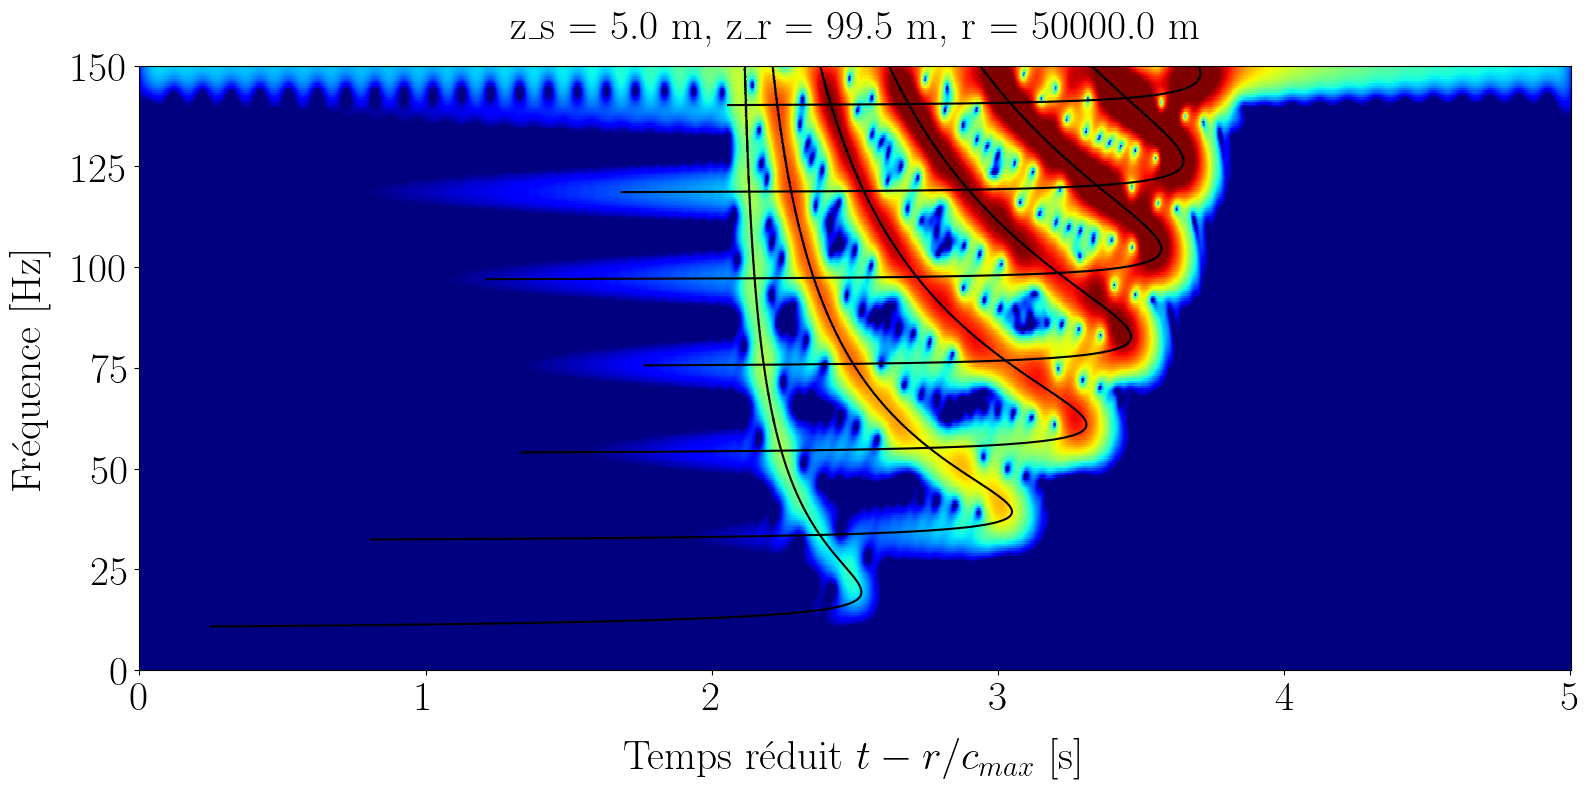

In [15]:
# Stft and theoretical dispersion curves
plot_impulse_response_stft_dispersion_curve(
    t,
    gt,
    z_s,
    z,
    r0,
    fmax,
    freq,
    cgm,
    tau=tau,
    nfft=nfft,
    nperseg=nperseg,
    noverlap=noverlap,
    stft_vmin_percentile=80,
    stft_vmax_percentile=99,
)

Ici la propagation s'interprète en termes de modes. Les modes résultent de l'interférence des arrivées multiples dues aux réflexions aux interfaces du guide d'onde. A haute fréquence, c'est-à-dire lorsque le rapport $\frac{\lambda}{D}$ devient petit devant 1, la propagation s'interprète plus aisément à l'aide de la théorie des rayons ou, dans le cas d'un guide d'onde isocèlère, par la méthode des sources-images.

Ici, on en considère que les modes propagatifs. En effet, les solutions réelles de l'équation transcendante correspondent aux modes qui se propagent sans atténuation autre que l'atténuation dû à la divergence géométrique. On peut montrer que les solutions réelles de l'équation transcendante sont telles que : 

$$
\lvert k_2 \rvert < \lvert k_r \rvert < \lvert k_1 \rvert 
$$

L'angle d'un mode $m$ dans l'eau est donné par : 

$$
\theta_m = \arccos{\frac{k_{rm}}{k_1}}
$$

Ainsi, dans le cas limite $k_{rm} = k_2$ :  

$$
\theta_m = \arccos{\frac{k_2}{k_1}} = \arccos{\frac{c_1}{c_2}} = \theta_c 
$$

où $\theta_c = \arccos{\frac{c_1}{c_2}}$ est l'angle de rasance critique à l'interface entre deux fluides de célérité respective $c_1$ et $c_2$.

On a donc, $\theta_m < \theta_c$ par décroissance de la fonction $\arccos()$. 

## Lien avec la méthode source - images 

## D = 200 m

In [16]:
###### Green's function at z, r ######
d_ = 200
z_ = d_ - 0.5
gf = pekeris_green_fct(freq, c1, c2, rho1, rho2, attn2, d_, z_s, z_, r0)
gf = gf.squeeze()
# Impulse response
output_mult_fact = 2
tau = r0 / max(c1, c2)  # Minimum arrival time
t, gt = impulse_response(gf, freq, fs, tau=tau, output_mult_fact=output_mult_fact)

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: ylabel='h(t) [Pa]'>, <Axes: ylabel='Fréquence [Hz]'>],
       dtype=object))

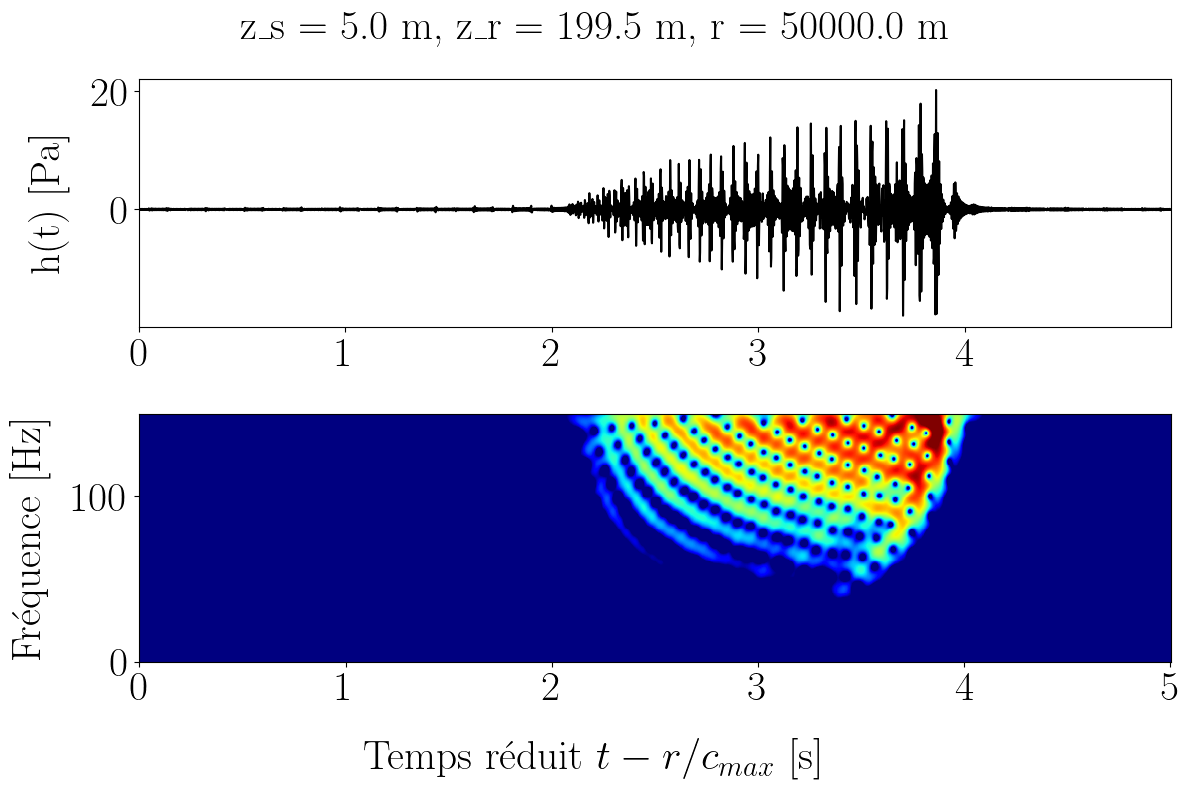

In [17]:
# stft
nfft = 1024
nperseg = 51 * output_mult_fact
noverlap = nperseg - 1

plot_impulse_response_and_stft(
    t,
    gt,
    z_s,
    z_,
    r0,
    fmax,
    nfft=nfft,
    nperseg=nperseg,
    noverlap=noverlap,
    stft_vmin_percentile=90,
    stft_vmax_percentile=99.9,
)

Ici la structure modale du signal est toujours clairement identifiable, l'interférence des différents modes donne naissance à des pics dans le signal temporel caractéristiques d'arrivées successives. 

## D = 1000 m

In [18]:
###### Green's function at z, r ######
d_ = 1000
z_ = d_ - 0.5
gf = pekeris_green_fct(freq, c1, c2, rho1, rho2, attn2, d_, z_s, z_, r0)
gf = gf.squeeze()
# Impulse response
output_mult_fact = 2
tau = r0 / max(c1, c2)  # Minimum arrival time
t, gt = impulse_response(gf, freq, fs, tau=tau, output_mult_fact=output_mult_fact)

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: ylabel='h(t) [Pa]'>, <Axes: ylabel='Fréquence [Hz]'>],
       dtype=object))

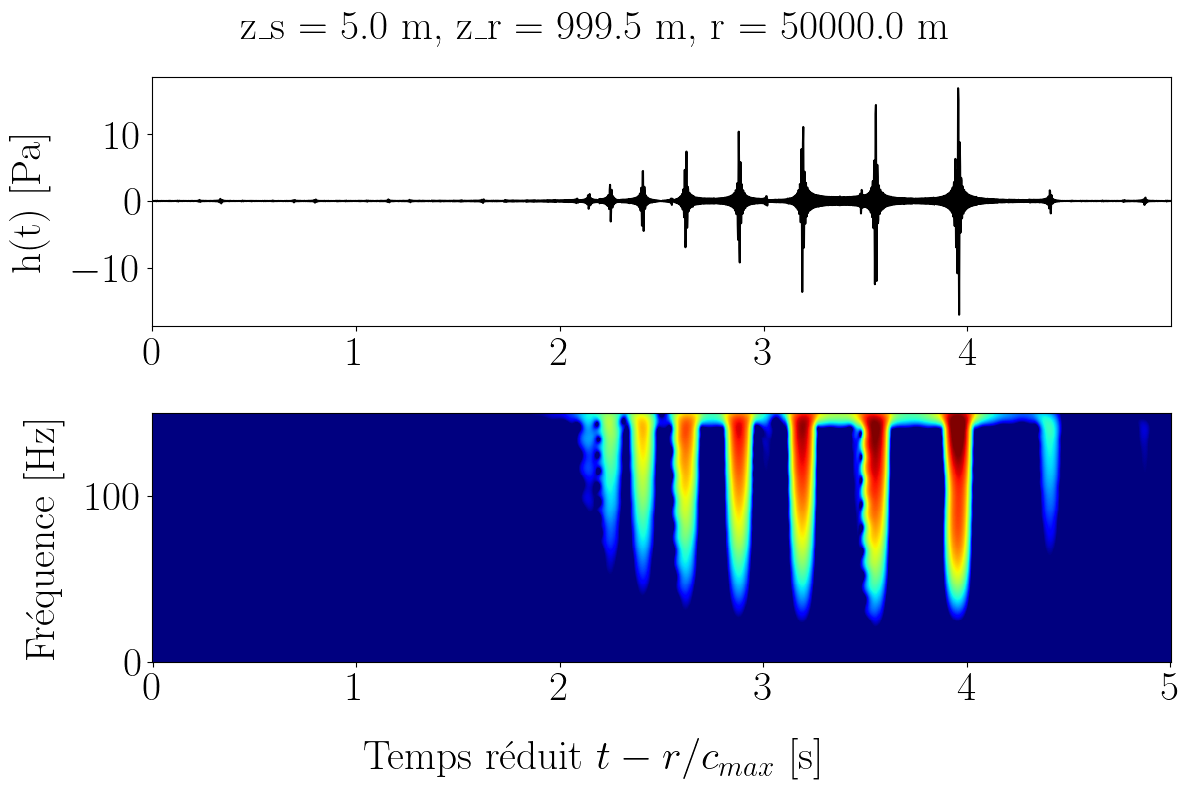

In [19]:
# stft
nfft = 1024
nperseg = 51 * output_mult_fact
noverlap = nperseg - 1

plot_impulse_response_and_stft(
    t,
    gt,
    z_s,
    z_,
    r0,
    fmax,
    nfft=nfft,
    nperseg=nperseg,
    noverlap=noverlap,
    stft_vmin_percentile=90,
    stft_vmax_percentile=99.9,
)

In [20]:
lambda_mean = c1 / 50
print(f"lambda_mean = {lambda_mean} m")
print(f"lambda_mean / D  = {lambda_mean/d_:.3f}")

lambda_mean = 30.0 m
lambda_mean / D  = 0.030


En grand fond (ici $\frac{\lambda}{D} \sim 3 \times 10^{-2}$), la propagation s'interprète plus facilement en termes de rayons.  

m = 0 : 
	 t1 = 33.33992621634174s 
	 t2 = 33.33993948038232s 
	 t3 = 33.34005945638903s 
	 t4 = 33.34007285368298s 

m = 1 : 
	 t1 = 33.393060025833044s 
	 t2 = 33.39309988771799s 
	 t3 = 33.39345924146091s 
	 t4 = 33.39349923596241s 

m = 2 : 
	 t1 = 33.499220755447766s 
	 t2 = 33.49928702558044s 
	 t3 = 33.499884047892195s 
	 t4 = 33.49995044938292s 

m = 3 : 
	 t1 = 33.657906650757575s 
	 t2 = 33.65799901789898s 
	 t3 = 33.65883090496295s 
	 t4 = 33.65892340161158s 

m = 4 : 
	 t1 = 33.86837942027277s 
	 t2 = 33.86849745871687s 
	 t3 = 33.86956037670272s 
	 t4 = 33.869678542253034s 

m = 5 : 
	 t1 = 34.12968099111909s 
	 t2 = 34.12982417020177s 
	 t3 = 34.13111334089307s 
	 t4 = 34.13125664418337s 

m = 6 : 
	 t1 = 34.44065446693938s 
	 t2 = 34.44082216240231s 
	 t3 = 34.442331965507535s 
	 t4 = 34.44249978184252s 

m = 7 : 
	 t1 = 34.79996826467263s 
	 t2 = 34.8001597713446s 
	 t3 = 34.80188385865212s 
	 t4 = 34.802075482489386s 

m = 8 : 
	 t1 = 35.206142331827394s 
	 t2 = 35.206

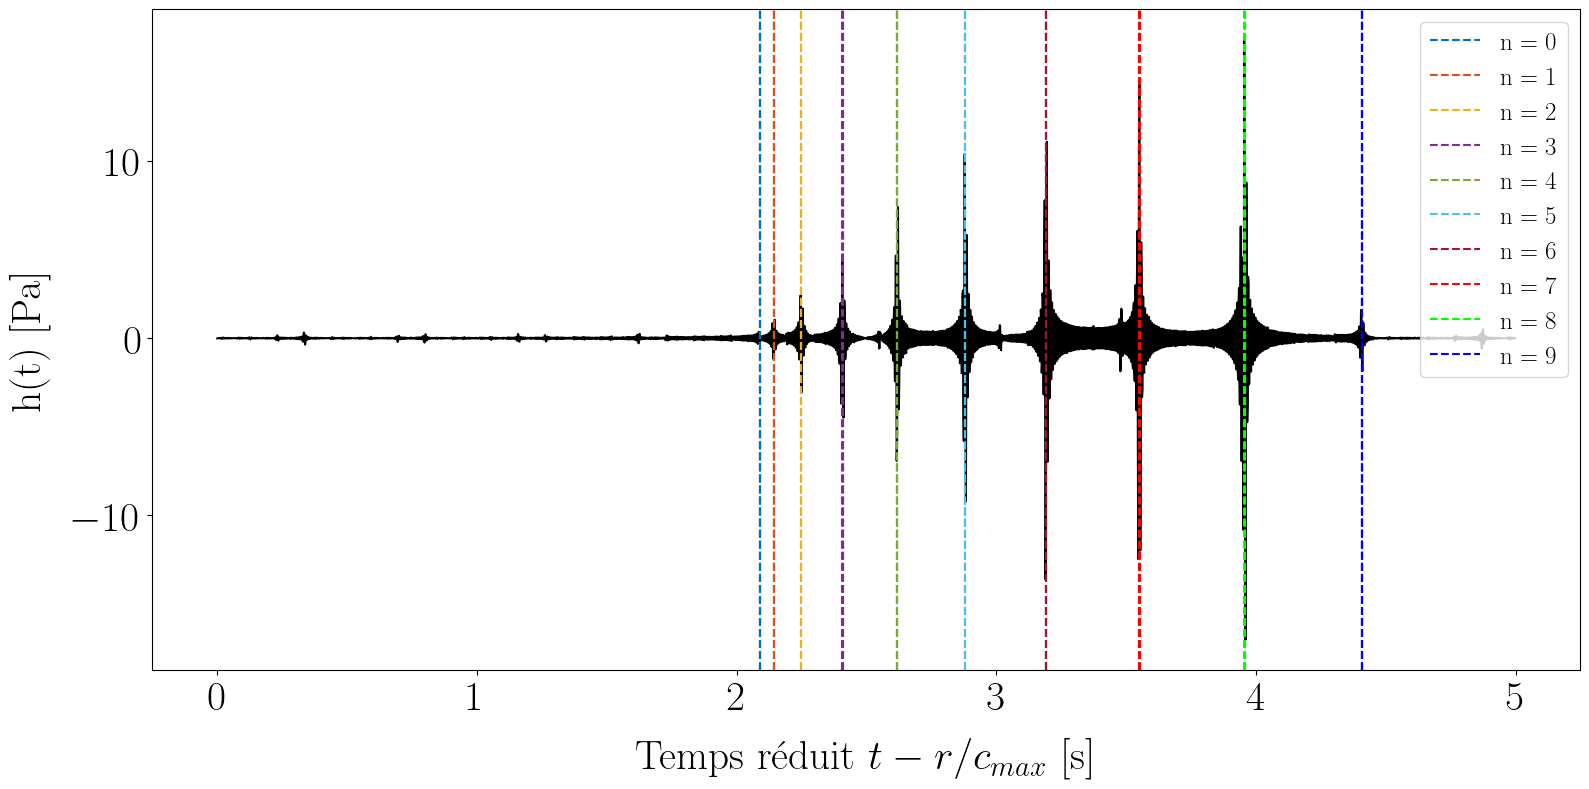

In [21]:
# Comparison to source image method
n_img = 10
arrivals = image_sources_arrivals(z_src=z_s, z_rcv=z_, r=r0, depth=d_, n=n_img, c0=c1)
grouped_arrivals = group_image_source_arrivals(arrivals)
fig, ax = plot_impulse_response_and_source_image_arrivals(
    t, gt, z_s, z_, r0, arrivals, tau=tau
)
ax.legend(fontsize=18)
plt.title("")
print(grouped_arrivals)

On distingue clairement 5 groupes d'arrivées. 

# Réponse fréquentielle du guide d'onde 

In [22]:
# Back to D = 100 m
g_fr = pekeris_green_fct(freq, c1, c2, rho1, rho2, attn2, d, z_s, z, r_grid)
idx_r0 = np.argmin(np.abs(r_grid - r0))
gf = g_fr[:, idx_r0]

## Fonction de transfert à r fixé 

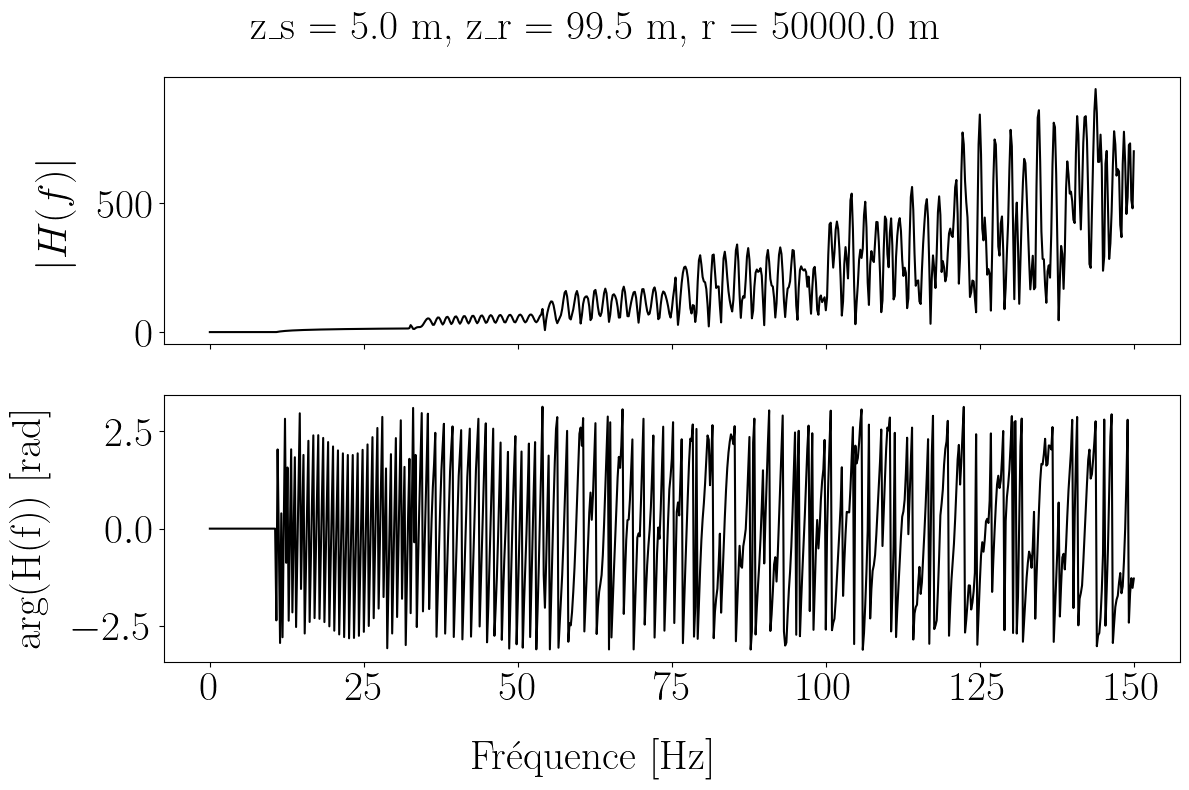

In [23]:
# Plot Green's function
fig, axs = plot_green_fct(freq, gf, z_s=z_s, z_r=z, r=r0)

### Fréquence de coupure des modes 

In [24]:
M = pekeris_n_modes(fmax, c1, c2, d)
f_c = [pekeris_cutoff_frequency(m, c1, c2, d) for m in range(1, M)]
f_c

[10.776318121606495,
 32.32895436481949,
 53.881590608032475,
 75.43422685124547,
 96.98686309445846,
 118.53949933767146]

Text(0.5, 0.98, '')

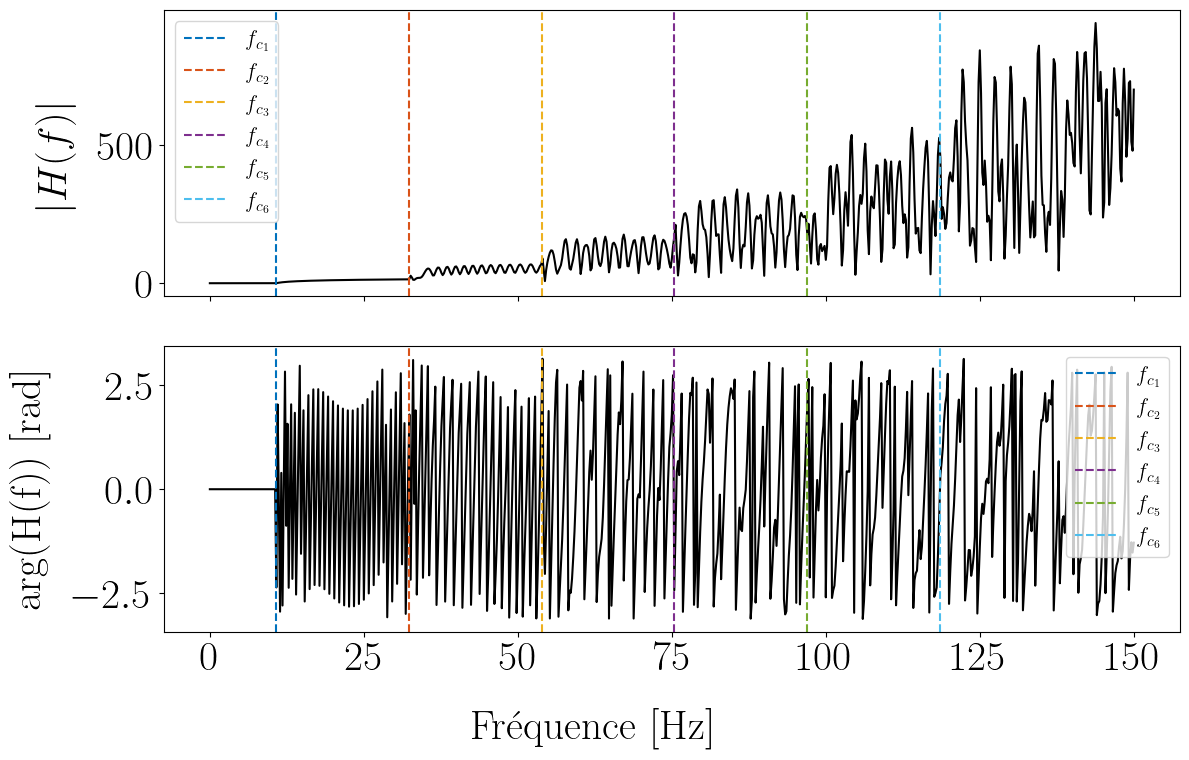

In [25]:
# Plot Green's function
fig, axs = plot_green_fct(freq, gf, z_s=z_s, z_r=z, r=r0)

for ax in axs.flatten():
    for i, fc in enumerate(f_c):
        lab = f"c_{i+1}"
        ax.axvline(fc, linestyle="--", color=color(i), label=rf"$f_{{{lab}}}$")
    ax.legend(fontsize=16)
# plt.title("")
fig.suptitle("")

Les variations du module de la fonction de transfert sont marquées par le nombre de modes propagatifs :  
 
* En dessous de $f = f_{c_1}$, il n'y a aucun mode propagatif, la fonction de transfert est nulle. 
 
* Entre  $f_{c_1}$ et $f_{c_2}$, il y a un unique mode propagatif, la fonction de transfert varie lentement en fréquence.
 
* Entre $f_{c_2}$ et $f_{c_3}$, il y a deux modes propagatifs qui interférent.

La phase de la fonction de transfert évolue rapidement en fréquence. Plus le nombre de modes propagatifs est important plus la fréquence d'oscillation de la phase en fonction de la fréquence est élevée.  

-> Ajouter explication du caractère passe bas du guide de Pekeris. 

## Structures d'interférences dans le plan (r, f)

(<Figure size 1600x800 with 2 Axes>,
 <Axes: xlabel='Distance r [m]', ylabel='Fréquence [Hz]'>)

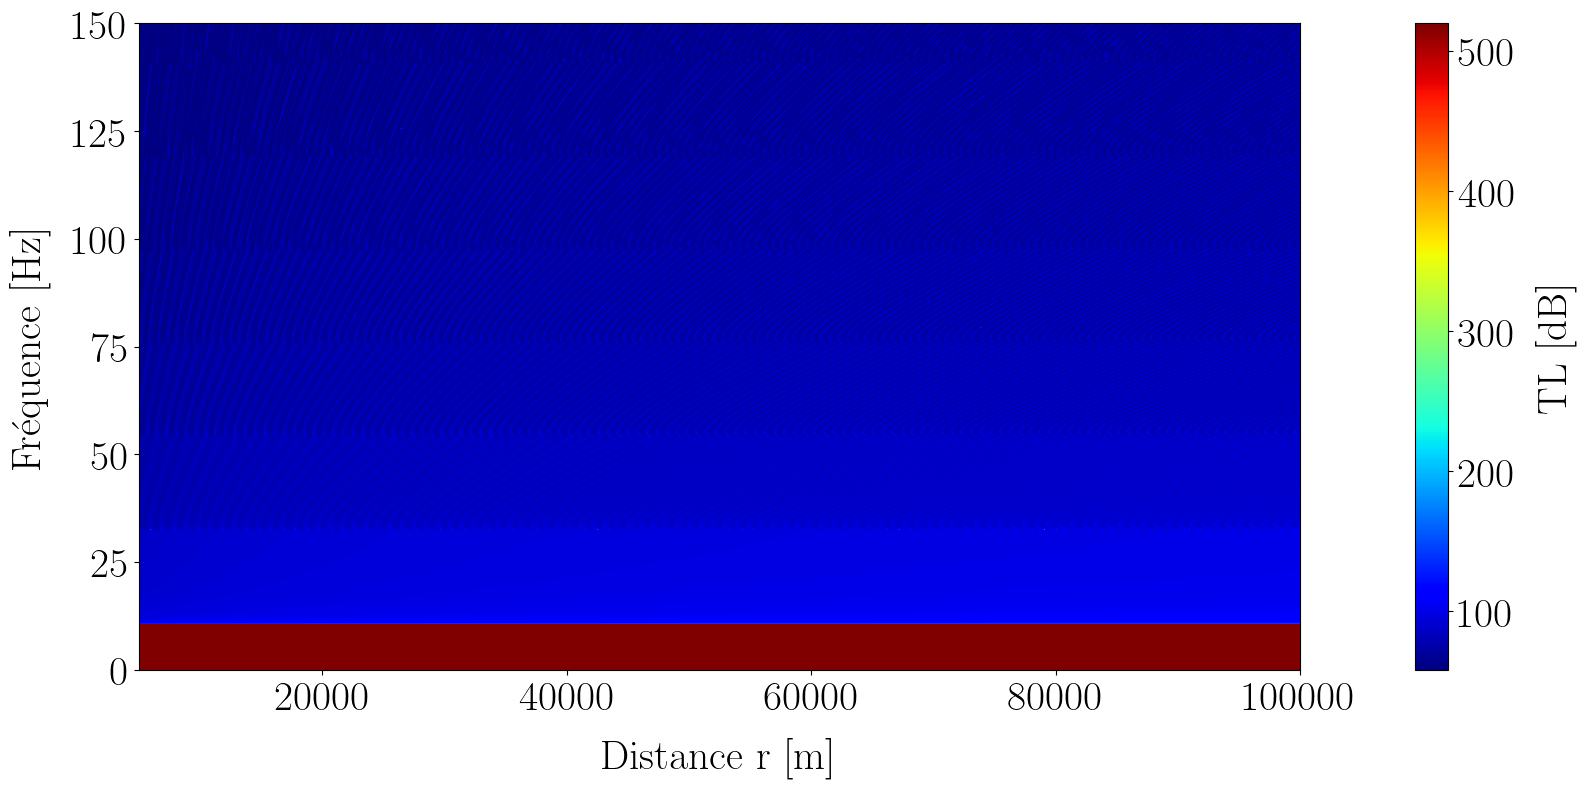

In [26]:
# Plot TL(f, r)
# idx_f_tl = np.logical_and(freq > 50, freq < 60)
# f_tl = freq[idx_f_tl]
# g_fr_ftl = g_fr[idx_f_tl, ...]
plot_tl_fr(
    g_fr,
    r_grid,
    freq,
    tl_vmin_percentile=1,
    tl_vmax_percentile=95,
)

On distingue les structures d'interférences caractérisées par leurres pentes elle-même liée à l'invariant de guide d'onde océanique.   

(<Figure size 1600x800 with 2 Axes>,
 <Axes: xlabel='Distance r [m]', ylabel='Fréquence [Hz]'>)

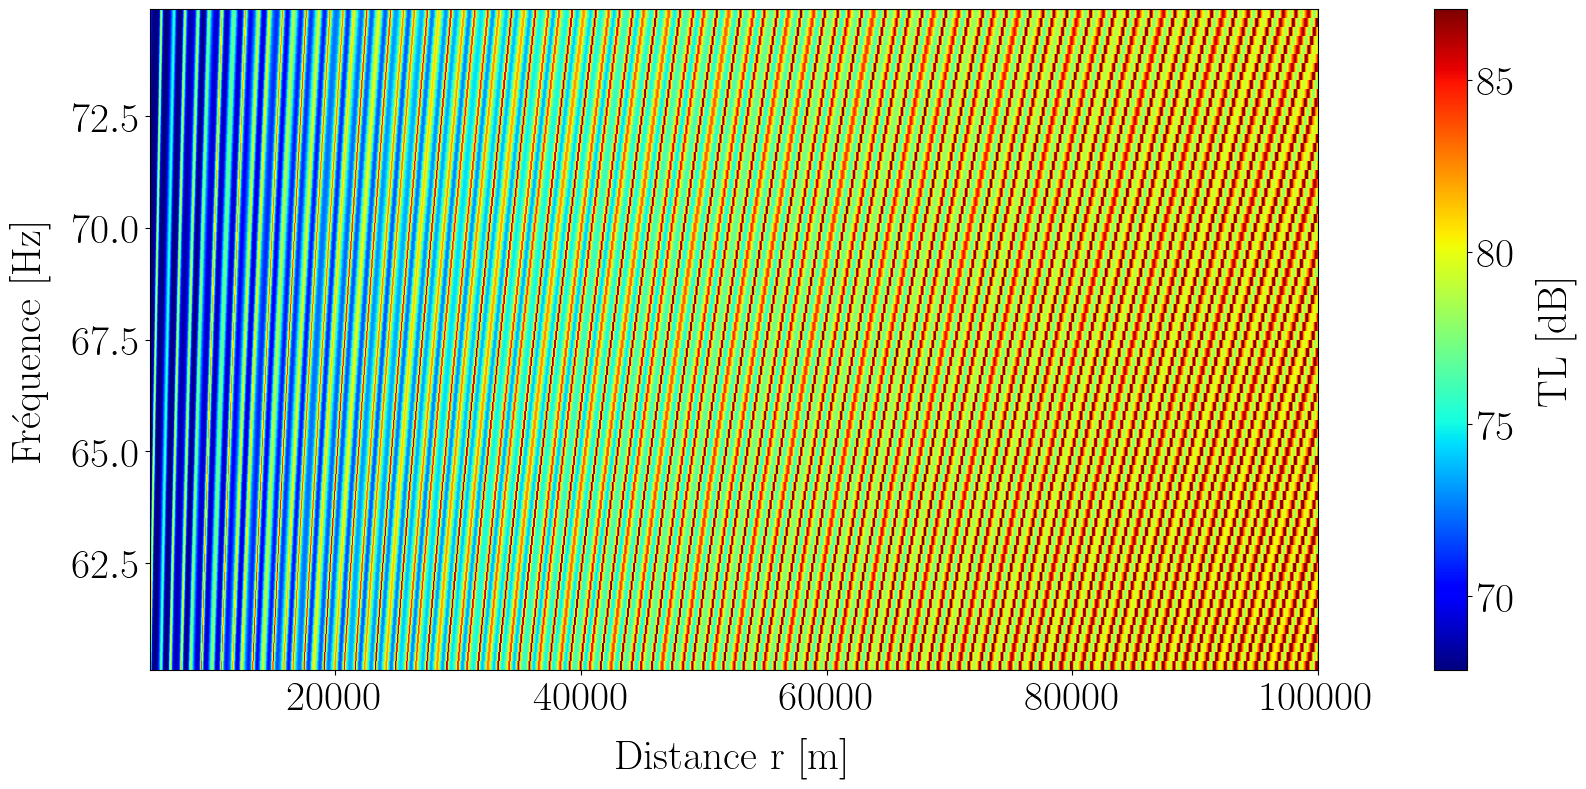

In [27]:
# Plot TL(f, r)
idx_f_tl = np.logical_and(freq > 60, freq < 75)
f_tl = freq[idx_f_tl]
g_fr_ftl = g_fr[idx_f_tl, ...]
plot_tl_fr(
    g_fr_ftl,
    r_grid,
    f_tl,
    tl_vmin_percentile=1,
    tl_vmax_percentile=95,
)

Localement, c'est-à-dire pour un groupe de modes donné et autour d'une fréquence donnée, les maximas et minimas des pertes suivent des droites dont la pente est donnée par l'invariant de guide d'onde océanique $\beta$. 

# Rapport des fonctions de transfert 

## Rapport $\Pi(f)$ à r fixé 

In [28]:
dr = r_grid[1] - r_grid[0]
r_grid_add = np.arange(r_grid[-1] + dr, r_grid[-1] + dr + d12, dr)
r_grid_ = np.append(r_grid, r_grid_add)
g_fr = pekeris_green_fct(freq, c1, c2, rho1, rho2, attn2, d, z_s, z, r_grid_)

nr_shift = int(d12 / dr)
# Green function at receiver 1
g_fr_1 = g_fr[:, 0:-nr_shift]
idx_1_r0 = np.argmin(np.abs(r_grid - r0))
gf1_r0 = g_fr_1[:, idx_1_r0]

# Green function at receiver 2
g_fr_2 = g_fr[:, nr_shift:]
idx_2_r0 = np.argmin(np.abs(r_grid - r0))
gf2_r0 = g_fr_2[:, idx_2_r0]

# gf1_r0 = pekeris_green_fct(freq, c_w, c_s, rho_w, rho_s, d, z_s, z, r0)
# gf2_r0 = pekeris_green_fct(freq, c_w, c_s, rho_w, rho_s, d, z_s, z, r0 + d12)
# idx_r0 = np.argmin(np.abs(r_grid - r0))
# idx_r0_d12 = np.argmin(np.abs(r_grid - (r0 + d12)))

# gf1_r0 = g_fr[:, idx_r0]
# gf2_r0 = g_fr[:, idx_r0_d12]

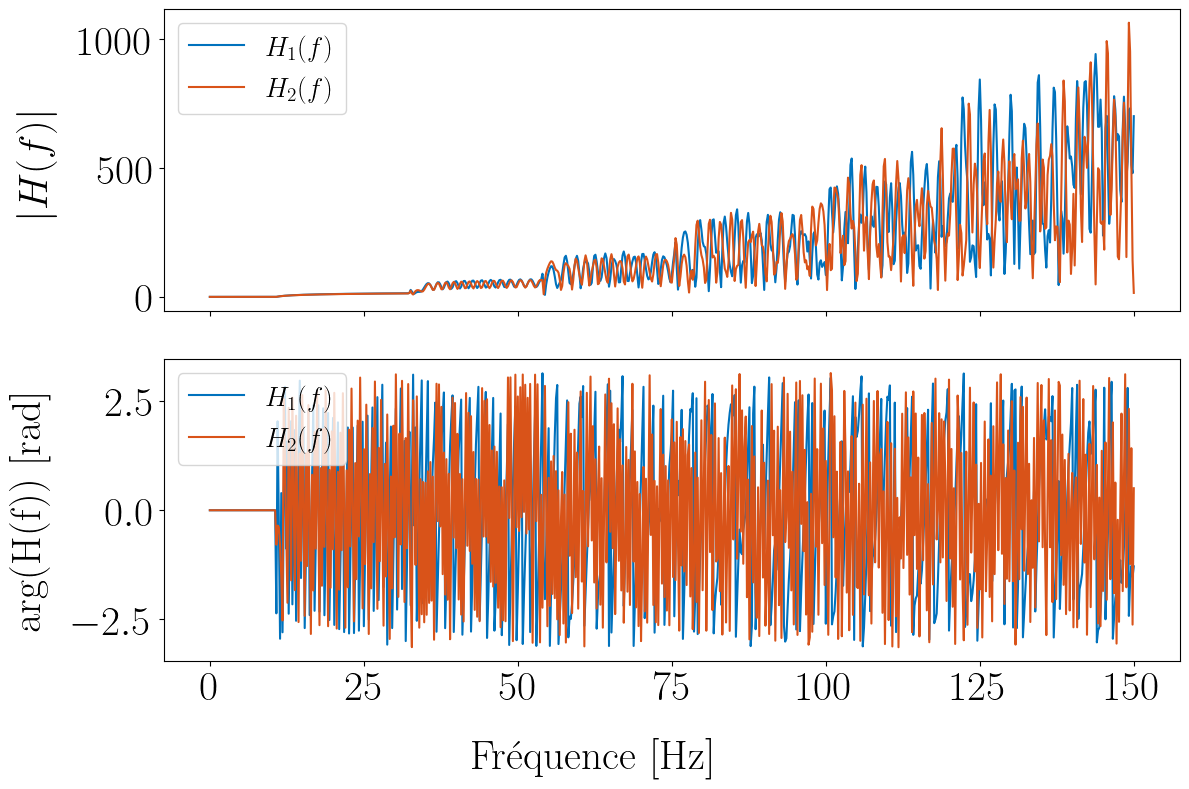

In [29]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Amplitude
axs[0].plot(freq, np.abs(gf1_r0), color=color(0), label="$H_1(f)$")
axs[0].plot(freq, np.abs(gf2_r0), color=color(1), label="$H_2(f)$")

axs[0].set_ylabel(r"$\lvert H(f) \rvert$")

# Phase
axs[1].plot(freq, np.angle(gf1_r0), color=color(0), label="$H_1(f)$")
axs[1].plot(freq, np.angle(gf2_r0), color=color(1), label="$H_2(f)$")

axs[1].set_ylabel("arg(H(f)) [rad]")

fig.supxlabel("Fréquence [Hz]")
# fig.suptitle(rf"z_s = {z_s:.1f} m, z_r = {z_r:.1f} m, r = {r:.1f} m")
for ax in axs:
    ax.legend()

D'après ce qui précède il apparait qu'à deux capteurs 1 et 2 séparés d'une distance $d_{12}$ sont associées des fonctions de transfert différentes. Pour une fréquence donnée, le passage de $H_1(f)$ à $H_2(f)$ est caractérisé par la pente des structures d'interférence observables dans le plan (r, f). 

In [30]:
pi_21_r0 = gf2_r0 / gf1_r0

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_20724\3796072305.py:1: RuntimeWarning: invalid value encountered in divide
  pi_21_r0 = gf2_r0 / gf1_r0


Text(0.5, 0.01, 'Fréquence [Hz]')

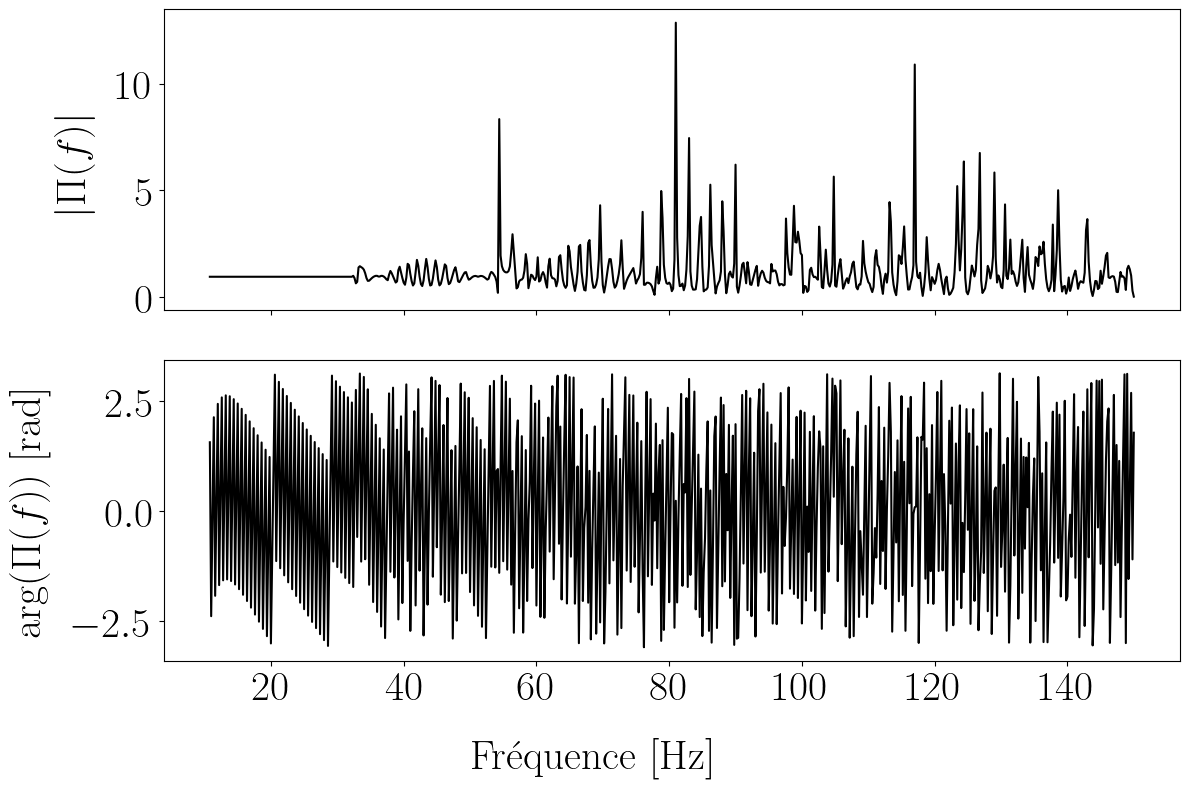

In [31]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Amplitude
axs[0].plot(freq, np.abs(pi_21_r0), color="k", label="$\Pi(f)$")
axs[0].set_ylabel(r"$\lvert \Pi(f) \rvert$")

# Phase
axs[1].plot(freq, np.angle(pi_21_r0), color="k", label="$\Pi(f)$")
axs[1].set_ylabel(r"arg($\Pi(f)$) [rad]")

# for ax in axs.flatten():
#     ax.set_xlim(freq[0], freq[-1])
# for ax in axs.flatten():
#     for i, fc in enumerate(f_c):
#         lab = f"c_{i+1}"
#         ax.axvline(fc, linestyle="--", color=color(i), label=rf"$f_{{{lab}}}$")
#     ax.legend(fontsize=16)

fig.supxlabel("Fréquence [Hz]")

Comme évoqué précédemment, l'argument de la fonction de transfert oscille très rapidement en fréquence. L'argument du rapport des fonctions de transfert oscille également rapidement. 

Dans la suite la grandeur d'intérêt est restreinte au module de $\Pi(f)$. 

## Pattern dans le plan (r, f) et lien avec l'invariant de guide d'onde

In [32]:
pi_21_fr = g_fr_2 / g_fr_1
gamma = 20 * np.log10(np.abs(pi_21_fr))

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_20724\2821390106.py:1: RuntimeWarning: invalid value encountered in divide
  pi_21_fr = g_fr_2 / g_fr_1


In [33]:
idx_f_tl = np.logical_and(freq > 60, freq < 75)
f_tl = freq[idx_f_tl]
g_fr_1_ftl = g_fr_1[idx_f_tl, ...]
g_fr_2_ftl = g_fr_2[idx_f_tl, ...]
gamma_ftl = gamma[idx_f_tl, ...]

In [34]:
idx_r_tl = np.logical_and(r_grid > 20 * 1e3, r_grid < 30 * 1e3)
r_tl = r_grid[idx_r_tl]
g_fr_1_ftl = g_fr_1_ftl[:, idx_r_tl]
g_fr_2_ftl = g_fr_2_ftl[:, idx_r_tl]
gamma_ftl = gamma_ftl[:, idx_r_tl]

In [35]:
tl_1 = transmission_loss(g_fr_1_ftl)
tl_2 = transmission_loss(g_fr_2_ftl)

Text(0.02, 0.5, 'Fréquence [Hz]')

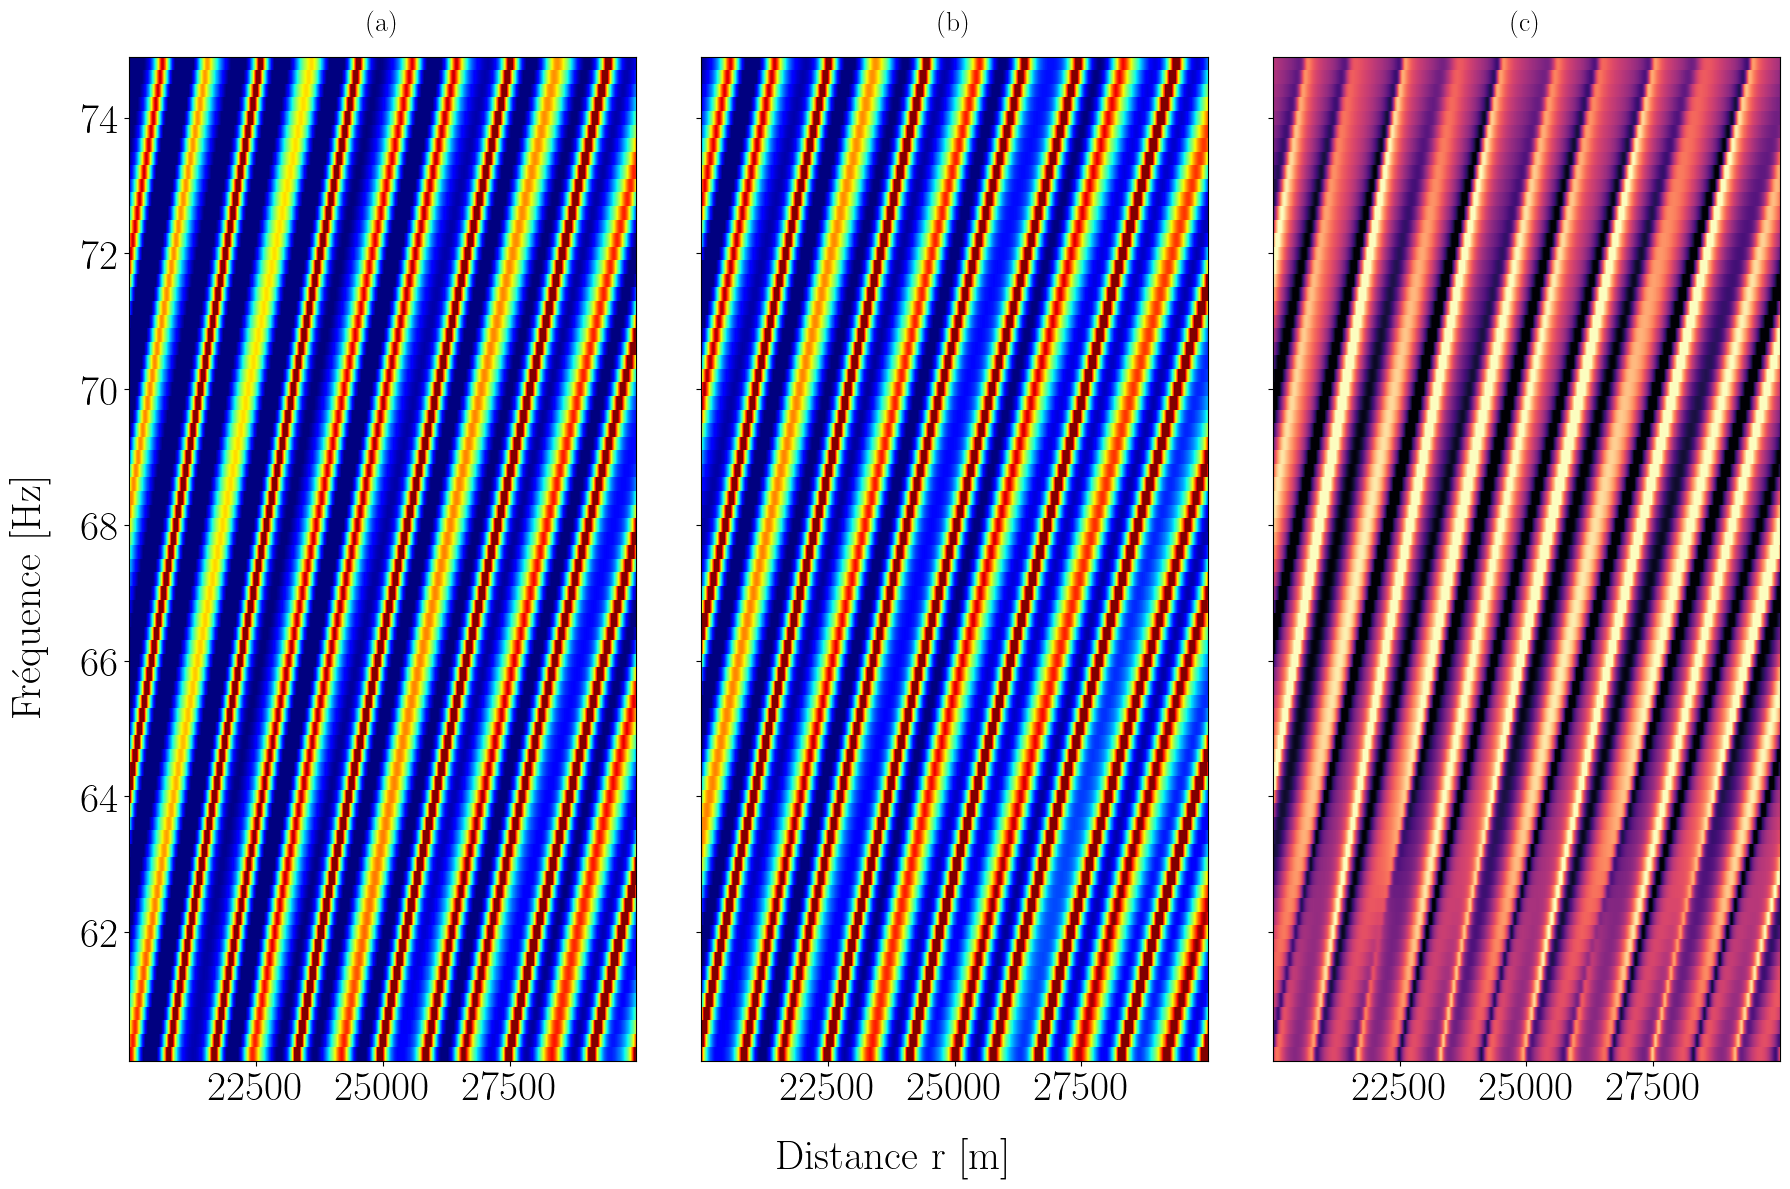

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(18, 12), sharex=True, sharey=True)

vmin = max(np.percentile(tl_1, 5), np.percentile(tl_2, 5))
vmax = min(np.percentile(tl_1, 95), np.percentile(tl_2, 95))

im = axs[0].pcolormesh(r_tl, f_tl, tl_1, vmin=vmin, vmax=vmax, cmap="jet")
im = axs[1].pcolormesh(r_tl, f_tl, tl_2, vmin=vmin, vmax=vmax, cmap="jet")

vmin = np.percentile(gamma_ftl, 5)
vmax = np.percentile(gamma_ftl, 95)
im = axs[2].pcolormesh(r_tl, f_tl, gamma_ftl, vmin=vmin, vmax=vmax, cmap="magma")

set_subfigures_abc_labels(axs, x_pos=0.5, y_pos=1.02, fontsize=20, ha="center", va="bottom")

fig.supxlabel("Distance r [m]")
fig.supylabel("Fréquence [Hz]")
# plt.colorbar(im, label="TL [dB]")

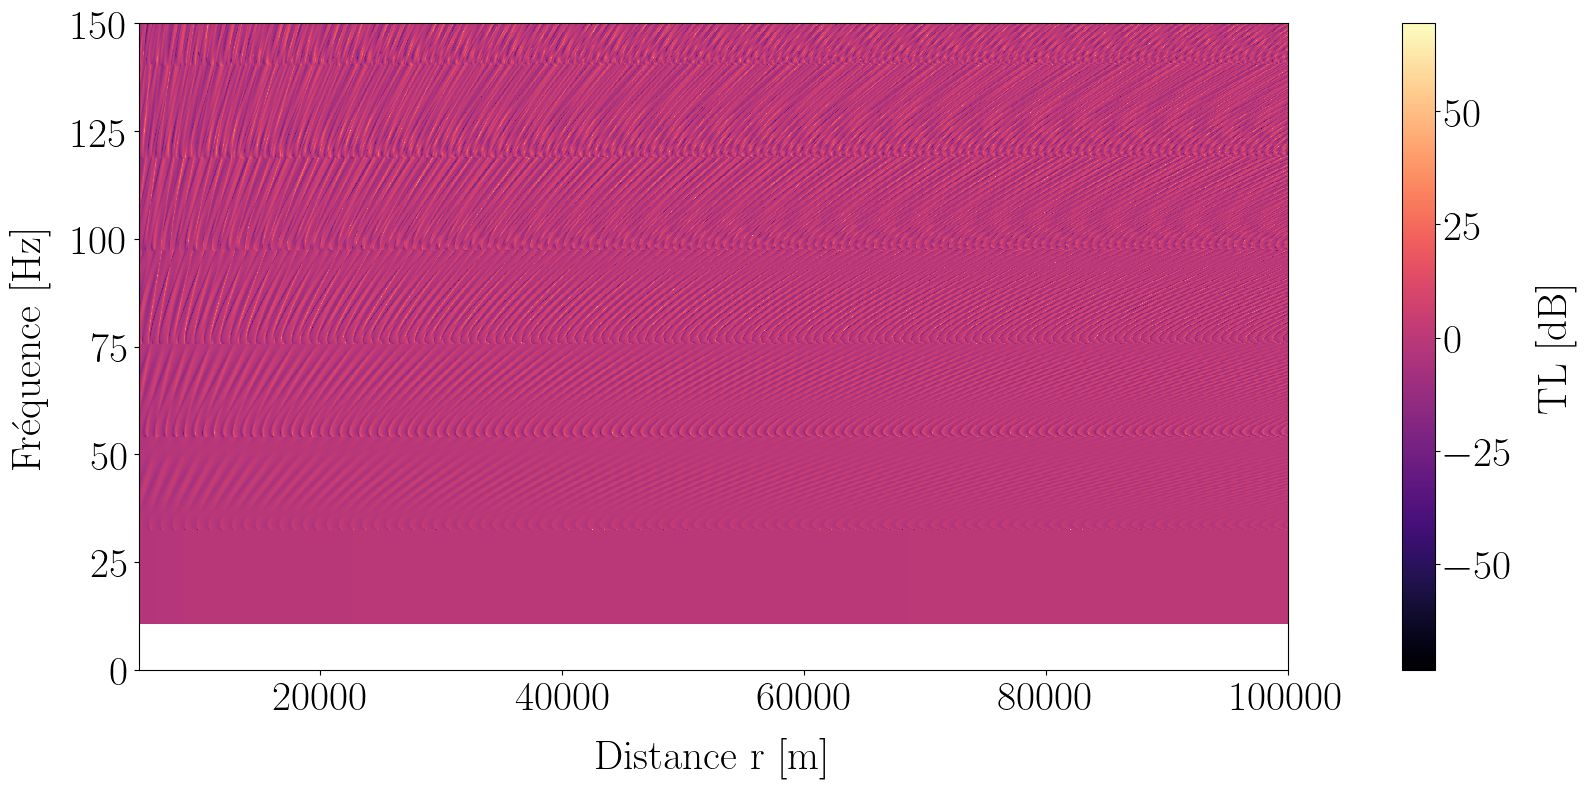

In [37]:
plt.figure()
# im = plt.pcolormesh(r_grid, freq, gamma, vmin=tlmin, vmax=tlmax, cmap="jet")
im = plt.pcolormesh(r_grid, freq, gamma, cmap="magma")

plt.xlabel("Distance r [m]")
plt.ylabel("Fréquence [Hz]")
plt.colorbar(im, label="TL [dB]")

# Illustration des variations 

## Quelques positions 

In [38]:
r_test = np.array([49, 50, 51]) * 1e3

Text(0.5, 0, 'Fréquence [Hz]')

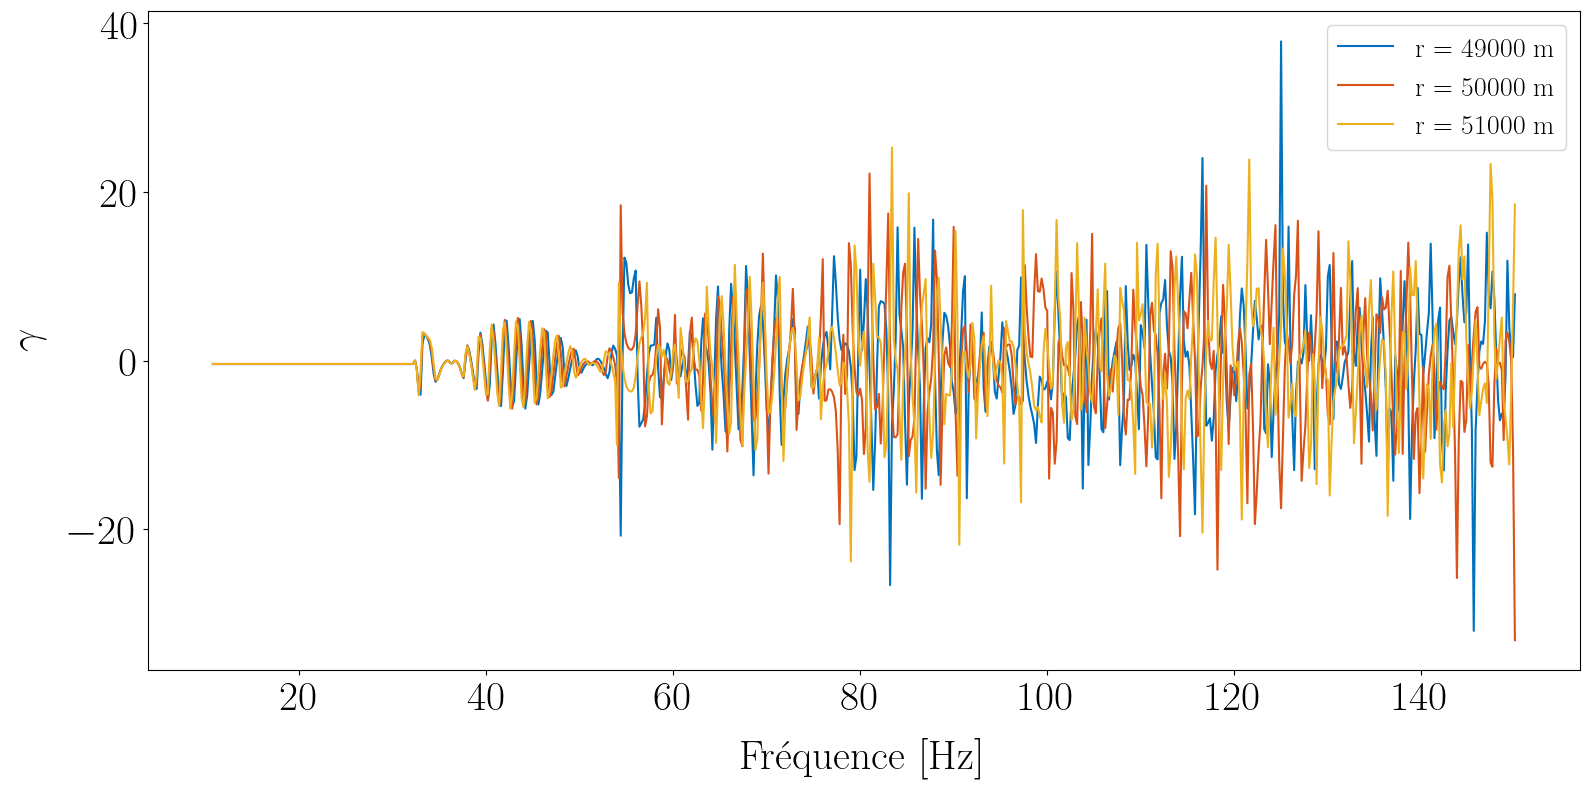

In [39]:
for i, r_i in enumerate(r_test):
    idx_ri = np.argmin(np.abs(r_grid - r_i))
    gamma_ri = gamma[:, idx_ri]

    plt.plot(freq, gamma_ri, color=color(i), label=f"r = {r_grid[idx_ri]:.0f} m")

plt.legend()
plt.ylabel(r"$\gamma$")
plt.xlabel("Fréquence [Hz]")
# plt.xscale("log")

## Calcul de distance 

In [40]:
idx_r0 = np.argmin(np.abs(r_grid - r0))
gamma_r0 = gamma[:, idx_r0]

dist_L1 = calc_gamma_dist(
    gamma_a=gamma_r0[:, np.newaxis], gamma_b=gamma, dist_type="L1"
)
dist_L2 = calc_gamma_dist(
    gamma_a=gamma_r0[:, np.newaxis], gamma_b=gamma, dist_type="L2"
)
dist_theta = calc_gamma_dist(
    gamma_a=gamma_r0[:, np.newaxis], gamma_b=gamma, dist_type="theta"
)
dist_L1 /= np.max(dist_L1)
dist_L2 /= np.max(dist_L2)
dist_theta /= np.max(dist_theta)

Text(0, 0.5, 'Distance')

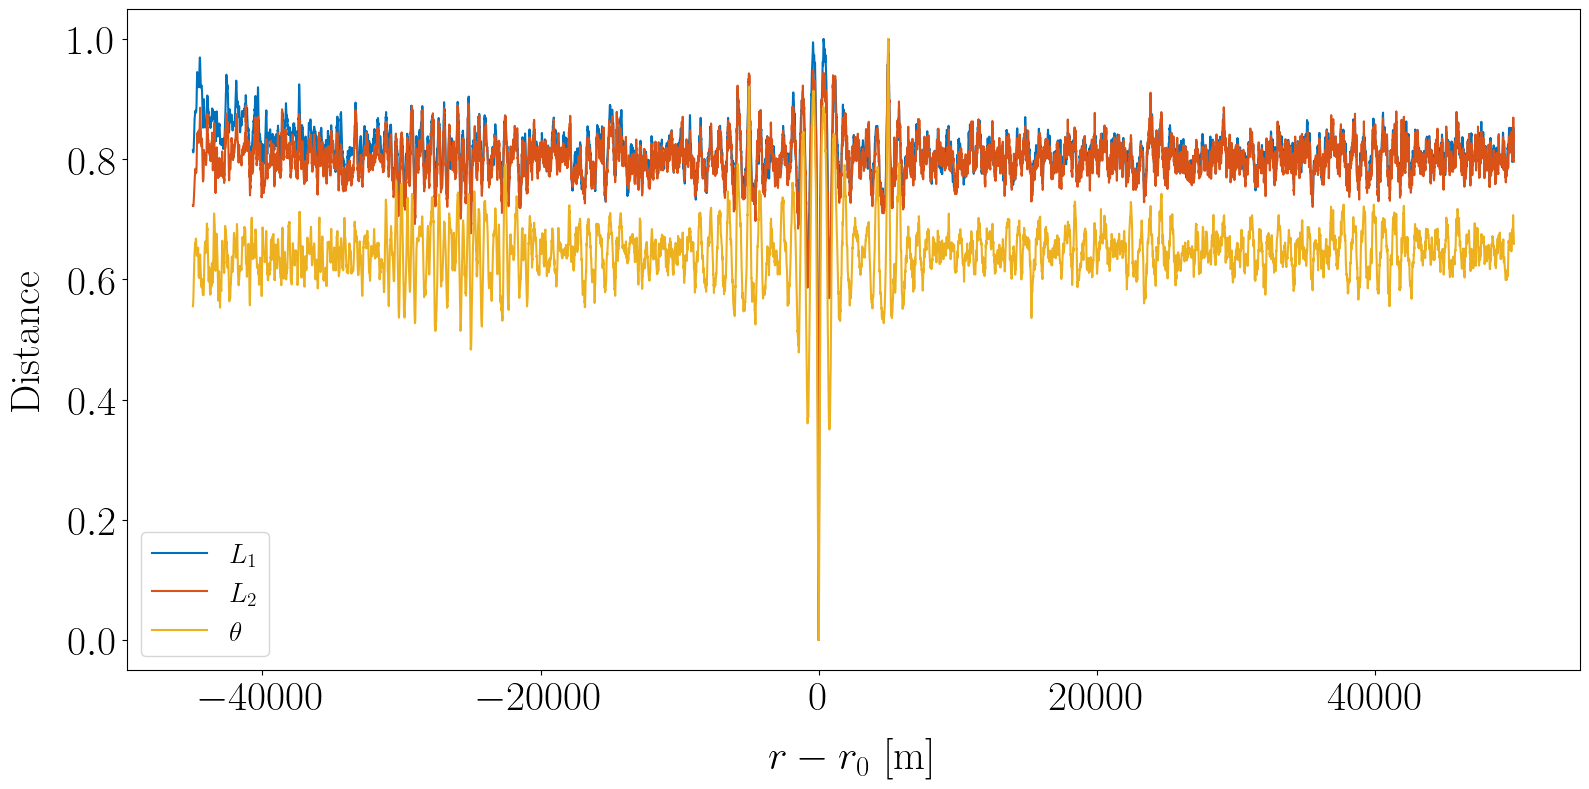

In [41]:
plt.figure()
plt.plot(r_grid-r0, dist_L1, color=color(0), label="$L_1$")
plt.plot(r_grid-r0, dist_L2, color=color(1), label="$L_2$")
plt.plot(r_grid-r0, dist_theta, color=color(2), label=r"$\theta$")
plt.legend()

plt.xlabel("$r - r_0$ [m]")
plt.ylabel("Distance")

Les trois métriques considérées ont un comportement similaire. Le domaine de variations monotones de la distance est relativement restreint. 

La sensibilité est caractérisée par la largeur du lobe principale défini par la taille du domaine de monotonie. 

## Calcul du domaine de monotonie 

In [42]:
domain_L1, r_domain_L1_inf,  r_domain_L1_sup = calc_monotonicity_domain(dist_r_r0=dist_L1, r=r_grid, r0=r0)
domain_L2, r_domain_L2_inf, r_domain_L2_sup = calc_monotonicity_domain(
    dist_r_r0=dist_L2, r=r_grid, r0=r0
)
domain_theta, r_domain_theta_inf, r_domain_theta_sup = calc_monotonicity_domain(
    dist_r_r0=dist_theta, r=r_grid, r0=r0
)

Text(0.5, 0, '$r - r_0$ [m]')

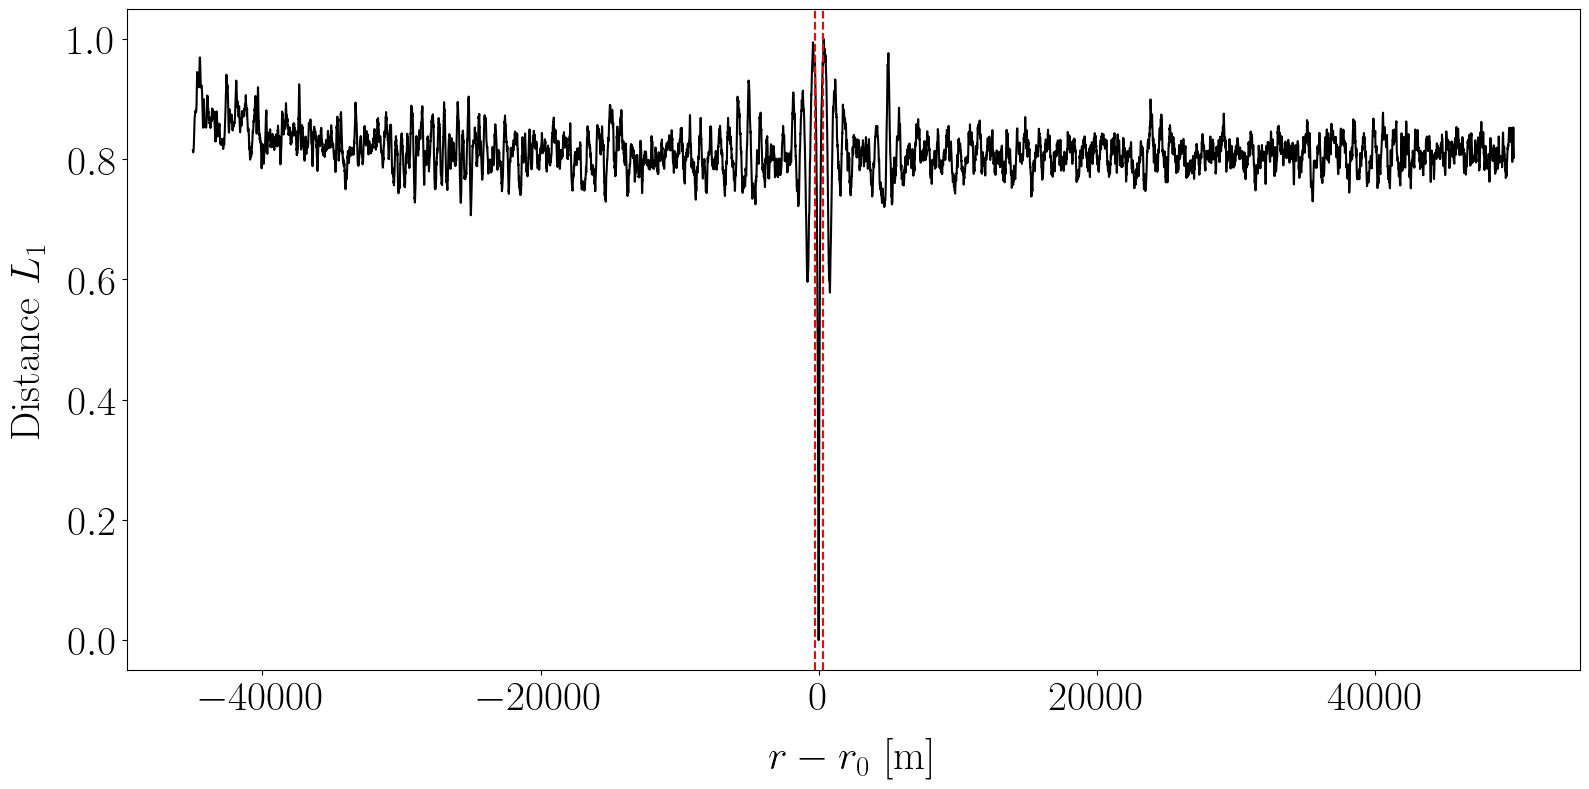

In [43]:
plt.figure()
plt.plot(r_grid-r0, dist_L1, color="k")
plt.axvline(r_domain_L1_inf, linestyle="--", color="r")
plt.axvline(r_domain_L1_sup, linestyle="--", color="r")
plt.ylabel(r"Distance $L_1$")

# plt.plot(r_grid - r0, dist_L2, color="k")
# plt.axvline(r_domain_L2_inf, linestyle="--", color="r")
# plt.axvline(r_domain_L2_sup, linestyle="--", color="r")
# plt.ylabel(r"Distance $L_2$")

# plt.plot(r_grid - r0, dist_theta, color="k")
# plt.axvline(r_domain_theta_inf, linestyle="--", color="r")
# plt.axvline(r_domain_theta_sup, linestyle="--", color="r")
# plt.ylabel(r"Distance $\theta$")

plt.xlabel("$r - r_0$ [m]")

In [44]:
ml_width_L1, r_ml_width_L1_inf, r_ml_width_L1_sup = calc_mainlobe_width_3dB(
    dist_r_r0=dist_L1, r=r_grid, r0=r0
)
ml_width_L2, r_ml_width_L2_inf, r_ml_width_L2_sup = calc_mainlobe_width_3dB(
    dist_r_r0=dist_L2, r=r_grid, r0=r0
)
ml_width_theta, r_ml_width_theta_inf, r_ml_width_theta_sup = calc_mainlobe_width_3dB(
    dist_r_r0=dist_theta, r=r_grid, r0=r0
)

Text(0.5, 0, '$r - r_0$ [m]')

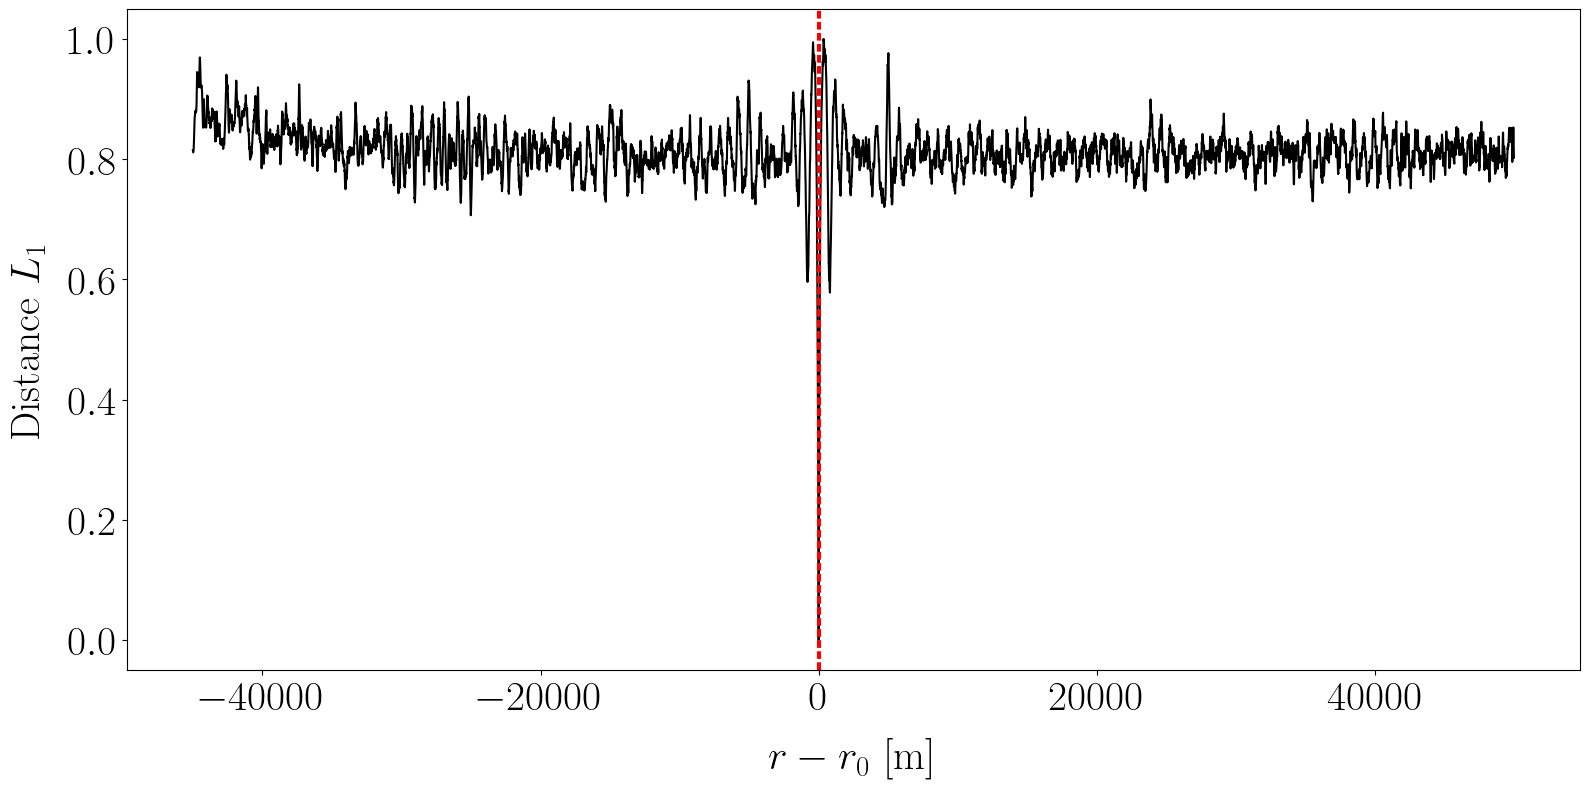

In [45]:
plt.figure()
plt.plot(r_grid-r0, dist_L1, color="k")
plt.axvline(r_ml_width_L1_inf, linestyle="--", color="r")
plt.axvline(r_ml_width_L1_sup, linestyle="--", color="r")
plt.ylabel(r"Distance $L_1$")

# plt.plot(r_grid - r0, dist_L2, color="k")
# plt.axvline(r_ml_width_L2_inf, linestyle="--", color="r")
# plt.axvline(r_ml_width_L2_sup, linestyle="--", color="r")
# plt.ylabel(r"Distance $L_2$")

# plt.plot(r_grid - r0, dist_theta, color="k")
# plt.axvline(r_ml_width_theta_inf, linestyle="--", color="r")
# plt.axvline(r_ml_width_theta_sup, linestyle="--", color="r")
# plt.ylabel(r"Distance $\theta$")

plt.xlabel("$r - r_0$ [m]")

La définition avec la largeur du lobe à -3dB est probablement plus générique et plus simple à introduire par analogie à la largeur du lobe de directivité par exemple. 

# Procédure pour l'étude de sensibilité 

La procédure utilisée pour l'étude de sensibilité est implémentée dans la fonction run_single_sensibility_test qui s'articule en trois étapes. Pour un jeu de paramètres donné : 

* 1) Génération du jeu de données 
* 2) Calcul de la distance autour de la position $r_0$
* 3) Calcul de la largeur du lobe principal 


In [47]:
width_L1, width_L2, width_theta = run_single_sensibility_test(
    freq, c1, c2, rho1, rho2, attn2, d, z_s, z, r_grid, r0, d12
)

In [48]:
width_L1, width_L2, width_theta

(145.0, 130.0, 225.0)